# MAESTRO Piano Transcription trained on Kaggle

## 1. Dependencies and imports


In [1]:
%pip install -q pretty_midi torchinfo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 52.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
from __future__ import annotations

import gc
import json
import math
import os
import random
import time
import traceback
from dataclasses import asdict, dataclass, field, replace
from itertools import product
from pathlib import Path
from typing import Literal
from bisect import bisect_right
import h5py
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pretty_midi
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, Subset
from torchinfo import summary
from tqdm.auto import tqdm


## 2. Configs

I like having these as dataclasses so I can just do cfg.* everywhere and not have to use a crapton of uppercase global variables

In [ ]:
@dataclass
class PathConfig:
    maestro_root: Path = Path("/kaggle/input/datasets/alonhaviv/the-maestro-dataset-v3-0-0/maestro-v3.0.0")
    work_dir: Path = Path("/kaggle/working")
    train_h5_name: str = "maestro_train_cqt.h5"
    validation_h5_name: str = "maestro_validation_cqt.h5"

    @property
    def csv_path(self) -> Path:
        return self.maestro_root / "maestro-v3.0.0.csv"

    @property
    def train_h5(self) -> Path:
        return self.work_dir / self.train_h5_name

    @property
    def validation_h5(self) -> Path:
        return self.work_dir / self.validation_h5_name


@dataclass
class FeatureConfig:
    kind: Literal["cqt", "log_mel"] = "cqt"
    sample_rate: int = 44_100
    hop_length: int = 384
    cqt_bins_per_semitone: int = 3
    cqt_bins_per_octave: int = cqt_bins_per_semitone * 12 # 3 (bins/semitone) * 12
    cqt_extract_bins: int = 344 # More headroom towards nyquist limit for harmonic stacking. it will get cropped to 264 later
    mel_bins: int = 229
    fmin_hz: float = float(librosa.note_to_hz("A0"))
    fmax_hz: float | None = None
    midi_low: int = 21
    midi_high: int = 108
    

    @property
    def n_pitches(self) -> int:
        return self.midi_high - self.midi_low + 1  # 88

    @property
    def n_bins(self) -> int:
        if self.kind == "cqt":
            return self.n_pitches * self.cqt_bins_per_semitone  # 264
        return self.mel_bins

    @property
    def frames_per_second(self) -> float:
        return self.sample_rate / self.hop_length


@dataclass
class DataConfig:
    chunk_frames: int = 384
    chunk_hop_frames: int = 384
    keep_incomplete: bool = False
    onset_radius: int = 1
    onset_side_value: float = 0.5
    train_song_limit: int | None = 100
    validation_song_limit: int | None = None
    batch_size: int = 16
    num_workers: int = 4
    load_into_ram: bool = True # kaggle should have space for this. local machine prob not
    inference_batch_size: int = 8
    full_piece_validation_song_limit: int = 5




### Model, training, and decoder configuration

In [ ]:
@dataclass
class ModelConfig:
    name: Literal["baseline"] = "baseline"
    d_model: int = 128
    n_heads: int = 4
    dropout: float = 0.10


@dataclass
class TrainConfig:
    epochs: int = 30
    learning_rate: float = 3e-4
    weight_decay: float = 1e-4
    active_loss_weight: float = 5.0
    onset_loss_weight: float = 1.0
    onset_positive_weight: float = 0.65
    sustain_onset_negative_weight: float = 2.0
    offset_loss_weight: float = 1.0
    offset_positive_scale: float = 5.0
    sustain_offset_negative_weight: float = 3.0
    label_smoothing: float = 0.01
    grad_clip_norm: float = 1.0
    seed: int = 42
    resume_checkpoint: str | None = None
    checkpoint_prefix: str = "piano_transcriber"
    checkpoint_epoch: int = 22
    evaluate_every: int = 1
    max_validation_batches: int | None = 50


@dataclass
class DecoderConfig:
    active_start_threshold: float = 0.60
    active_continue_threshold: float = 0.40
    active_end_threshold: float = 0.10
    active_end_patience_frames: int = 3
    onset_threshold: float = 0.25
    onset_tolerance_frames: int = 2
    active_support_threshold: float = 0.25
    active_support_radius: int = 2
    onset_pre_max: int = 3
    onset_post_max: int = 3
    onset_min_gap_frames: int = 4
    offset_threshold: float = 0.25
    offset_pre_max: int = 3
    offset_post_max: int = 3
    offset_min_gap_frames: int = 4
    offset_tolerance_frames: int = 6
    min_note_frames: int = 2
    use_offset_head: bool = True
    offset_active_drop: float = 0.20
    offset_lookahead_frames: int = 4
    offset_peak_window_frames: int = 12
    default_velocity: float = 0.80


@dataclass
class ExperimentConfig:
    paths: PathConfig = field(default_factory=PathConfig)
    feature: FeatureConfig = field(default_factory=FeatureConfig)
    data: DataConfig = field(default_factory=DataConfig)
    model: ModelConfig = field(default_factory=ModelConfig)
    train: TrainConfig = field(default_factory=TrainConfig)
    decoder: DecoderConfig = field(default_factory=DecoderConfig)




### Runtime settings and shared constants

In [ ]:
CFG = ExperimentConfig()

# False by default so I can run all without getting stuck.
BUILD_TRAIN_H5 = False
BUILD_VALIDATION_H5 = False
RUN_TRAINING = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CFG.paths.work_dir.mkdir(parents=True, exist_ok=True)

# Love how I said I wouldn't use global variables and then immediately did... 
# CFG is now used directly so these values cannot drift away from the dataclasses.
CH_ACTIVE, CH_ONSET, CH_VEL = 0, 1, 2 # CH_VEL is unused so we don't have to worry about a collision here
CH_OFFSET = 2 # because CH_VEL is unused we can use 2 for our offsets
N_LABEL_CHANNELS = 3

# Used in decoder
END_REASON_NONE = 0
END_REASON_REONSET = 1
END_REASON_ACTIVE_DROPOUT = 2
END_REASON_GATED_OFFSET = 3

print(f"device={DEVICE} | feature={CFG.feature.kind} ({CFG.feature.n_bins} bins) | model={CFG.model.name}")


device=cuda | feature=cqt (264 bins) | model=baseline


In [4]:
def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True


seed_everything(CFG.train.seed)

## 3. MIDI to frame-label conversion


In [ ]:
# Couple of helpers here to convert between between real audio and frame indexes

def seconds_to_frame(t: float) -> int:
    #Convert a time in seconds to the nearest CQT frame index
    return int(round(t * CFG.feature.frames_per_second))


def frame_to_seconds(f: int) -> float:
    # Convert a CQT frame index back to its center time in seconds
    return f / CFG.feature.frames_per_second


def _pitch_to_idx(pitch: int) -> int | None:
    # Return matrix column for a MIDI pitch, or None if out of range.
    if CFG.feature.midi_low <= pitch <= CFG.feature.midi_high:
        return pitch - CFG.feature.midi_low
    return None

### MIDI-to-label conversion

In [ ]:
# Need this to generate our labels, since our model doesnt output a midi

def midi_to_label_matrix(
    midi_path: str,
    n_frames: int | None = None,
    pad_frames: int = 0,
    offset_seconds: float = 0.0,
) -> np.ndarray:
    """
    Load a MIDI file and return a (T, 88, 3) float32 label matrix.

    Parameters
    ----------
    midi_path : str
        Path to the midi file
    n_frames : int, optional
        Force the time axis to exactly this length.  If None, the length is
        derived from the last note-off event.
    pad_frames : int
        Extra frames appended after the last event (only used when n_frames
        is None).
    offset_seconds : float
        Shift all MIDI events forward in time by this many seconds before
        converting to frames.  Use this to align a MIDI that starts at t=0
        with a WAV that has a lead-in silence (will equal the first note time)

    Returns
    -------
    Y : np.ndarray, shape (T, 88, 3), dtype float32
    """
    pm = pretty_midi.PrettyMIDI(midi_path)

    # Determine matrix length
    if n_frames is not None:
        T = n_frames
    else:
        end_time = pm.get_end_time() + offset_seconds
        T = seconds_to_frame(end_time) + 1 + pad_frames

    Y = np.zeros((T, CFG.feature.n_pitches, N_LABEL_CHANNELS), dtype=np.float32)

    # This for loop is mainly for decoration as the main point of this model is for piano. I haven't seen if it would work with other instruments
    for instrument in pm.instruments:
        if instrument.is_drum:
            continue
        for note in instrument.notes:
            idx = _pitch_to_idx(note.pitch)
            if idx is None:
                continue

            f_on  = min(seconds_to_frame(note.start + offset_seconds), T - 1)
            f_off = min(seconds_to_frame(note.end   + offset_seconds), T - 1)

            # When onset and offset land on the same frame, keep at least 1
            if f_off <= f_on:
                f_off = f_on + 1
            f_off = min(f_off, T)          # exclusive upper bound for slice

            vel_norm = note.velocity / 127.0

            Y[f_on:f_off, idx, CH_ACTIVE] = 1.0
            Y[f_on,        idx, CH_ONSET]  = 1.0
            Y[f_on:f_off,  idx, CH_VEL]   = vel_norm

    return Y

### Label-to-MIDI conversion

In [ ]:
# This is how we're going to convert our model output back into a midi file. it's the exact inverse of midi_to_label_matrix

def label_matrix_to_midi(
    Y: np.ndarray,
    output_path: str | None = None,
    onset_threshold: float = 0.5,
    active_threshold: float = 0.5,
    tempo: float = 120.0,
    program: int = 0,
) -> pretty_midi.PrettyMIDI:
    """
    Reconstruct a PrettyMIDI object from a (T, 88, 3) label matrix.

    The reconstruction algorithm
    ----------------------------
    For each pitch i:
      • A note starts at frame t when onset[t,i] > threshold  (or when
        active[t,i] rises after being 0, as a fallback).
      • The note ends at the first frame where active[t,i] drops to 0,
        or at the last frame T if it never drops.
      • Velocity is the mean of vel[t,i] over the active span, re-scaled
        to 0-127 and clamped to [1, 127]. (Again unused but who knows it might be later)

    Parameters
    ----------
    Y : np.ndarray, shape (T, 88, 3)
    output_path : str, optional
        If given, write the MIDI to this path.
    onset_threshold : float
        Minimum value in CH_ONSET to declare a note start.
    active_threshold : float
        Minimum value in CH_ACTIVE to consider a note held.
    tempo : float
        BPM written into the output file (default 120).
    program : int
        General MIDI program number for the single output instrument.

    Returns
    -------
    pm : pretty_midi.PrettyMIDI
    """
    if Y.ndim != 3 or Y.shape[1] != CFG.feature.n_pitches or Y.shape[2] != N_LABEL_CHANNELS:
        raise ValueError(f"Expected shape (T, {CFG.feature.n_pitches}, {N_LABEL_CHANNELS}), got {Y.shape}")

    T = Y.shape[0]
    active  = Y[:, :, CH_ACTIVE] >= active_threshold   # (T, 88) bool
    onset   = Y[:, :, CH_ONSET]  >= onset_threshold    # (T, 88) bool
    vel_mat = Y[:, :, CH_VEL]                           # (T, 88) float

    pm = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=program)

    for i in range(CFG.feature.n_pitches):
        pitch = i + CFG.feature.midi_low
        t = 0
        while t < T:
            # Find a note start: prefer explicit onset, fall back to
            # active rising edge (handles matrices without onset channel)
            if onset[t, i] or (active[t, i] and (t == 0 or not active[t - 1, i])):
                note_start = t
                # Advance until the note ends: stop at active=0 OR a new onset on the same pitch (re-attack without a gap)
                t_end = t + 1
                while t_end < T and active[t_end, i] and not onset[t_end, i]:
                    t_end += 1

                # Mean velocity over the held frames
                vel_raw = vel_mat[note_start:t_end, i].mean()
                velocity = int(np.clip(round(vel_raw * 127), 1, 127))

                note = pretty_midi.Note(
                    velocity=velocity,
                    pitch=pitch,
                    start=frame_to_seconds(note_start),
                    end=frame_to_seconds(t_end),
                )
                instrument.notes.append(note)
                t = t_end   # jump past this note
            else:
                t += 1

    instrument.notes.sort(key=lambda n: n.start)
    pm.instruments.append(instrument)

    if output_path is not None:
        pm.write(output_path)

    return pm

### Round-trip verification

In [ ]:
# check that I actually know what i'm talking about and the forward/backward passes worked

def verify_roundtrip(
    midi_path: str,
    output_path: str | None = None,
    verbose: bool = True,
) -> dict:
    """
    Load a MIDI, convert to matrix, invert back, and report metrics.

    Returns a dict with keys:
      n_notes_original, n_notes_recovered,
      note_match_rate,
      mean_timing_error_ms, max_timing_error_ms,
      mean_velocity_error, max_velocity_error
    """
    pm_orig = pretty_midi.PrettyMIDI(midi_path)

    # Collect ground truth notes
    orig_notes = []
    for inst in pm_orig.instruments:
        if inst.is_drum:
            continue
        for note in inst.notes:
            if CFG.feature.midi_low <= note.pitch <= CFG.feature.midi_high:
                orig_notes.append(note)

    # Forward pass
    Y = midi_to_label_matrix(midi_path)

    # Inverse pass
    pm_rec = label_matrix_to_midi(Y, output_path=output_path)
    rec_notes = pm_rec.instruments[0].notes if pm_rec.instruments else []

    # Build lookup: (pitch, approx_frame) > original note
    orig_lookup: dict[tuple[int, int], pretty_midi.Note] = {}
    for note in orig_notes:
        key = (note.pitch, seconds_to_frame(note.start))
        orig_lookup[key] = note


    # This section checks how well the round-trip worked by comparing the original notes to the recovered notes
    timing_errors: list[float] = []
    velocity_errors: list[float] = []
    matched = 0

    for note in rec_notes:
        key = (note.pitch, seconds_to_frame(note.start))
        if key in orig_lookup:
            orig = orig_lookup[key]
            matched += 1
            timing_errors.append(abs(note.start - orig.start) * 1000)   # ms
            velocity_errors.append(abs(note.velocity - orig.velocity))

    n_orig = len(orig_notes)
    n_rec  = len(rec_notes)

    metrics = {
        "n_notes_original":    n_orig,
        "n_notes_recovered":   n_rec,
        "note_match_rate":     matched / n_orig if n_orig else 0.0,
        "mean_timing_error_ms": float(np.mean(timing_errors))   if timing_errors else 0.0,
        "max_timing_error_ms":  float(np.max(timing_errors))    if timing_errors else 0.0,
        "mean_velocity_error":  float(np.mean(velocity_errors)) if velocity_errors else 0.0,
        "max_velocity_error":   float(np.max(velocity_errors))  if velocity_errors else 0.0,
    }

    if verbose:
        print("── Round-trip verification ──────────────────────────")
        print(f"  Notes original   : {n_orig}")
        print(f"  Notes recovered  : {n_rec}")
        print(f"  Match rate       : {metrics['note_match_rate']:.1%}")
        print(f"  Timing error     : mean {metrics['mean_timing_error_ms']:.2f} ms"
              f"  /  max {metrics['max_timing_error_ms']:.2f} ms")
        print(f"  Velocity error   : mean {metrics['mean_velocity_error']:.2f}"
              f"  /  max {metrics['max_velocity_error']:.0f}")
        print("─────────────────────────────────────────────────────")

    return metrics


## 4. Audio feature extraction

Personally I ended up using CQT here over log mel because the frequency bins are spaced to match the frequencies of musical notes (both are logarithmic).

In [6]:
# Normalizes amplitude to dB and scales to [0, 1]
def _normalize_db_values(db: np.ndarray) -> np.ndarray:
    lo, hi = float(db.min()), float(db.max())
    return ((db - lo) / (hi - lo + 1e-8)).astype(np.float32) # hi - lo + 1e-8 is to avoid division by zero in case hi == lo


def normalize_db_feature(magnitude: np.ndarray) -> np.ndarray:
    db = librosa.amplitude_to_db(magnitude, ref=np.max)
    return _normalize_db_values(db)

# there is a logmel option for future testing in case I want to use it instead of cqt but for now we stick with cqt
def compute_features(audio_path: str | Path, cfg: FeatureConfig = CFG.feature) -> np.ndarray:
    #Return a time-first feature matrix with shape (frames, bins)
    y, _ = librosa.load(audio_path, sr=cfg.sample_rate, mono=True)

    if cfg.kind == "cqt":
        transform = librosa.cqt(
            y,
            sr=cfg.sample_rate,
            hop_length=cfg.hop_length,
            fmin=cfg.fmin_hz,
            n_bins=cfg.cqt_extract_bins,
            bins_per_octave=cfg.cqt_bins_per_octave, # 344
        )
        feature = normalize_db_feature(np.abs(transform).astype(np.float32))

    # unsupported rn
    elif cfg.kind == "log_mel":
        power = librosa.feature.melspectrogram(
            y=y,
            sr=cfg.sample_rate,
            hop_length=cfg.hop_length,
            n_mels=cfg.mel_bins,
            fmin=cfg.fmin_hz,
            fmax=cfg.fmax_hz,
            power=2.0,
        )
        db = librosa.power_to_db(power, ref=np.max)
        feature = _normalize_db_values(db)
    else:
        raise ValueError(f"Unknown feature kind: {cfg.kind}")

    return feature.T

# This is just to help with our hf attrs so that when we load a hdf5 we can see what feature config was used to generate it in case I ever change the feature config. 
def feature_signature(cfg: FeatureConfig) -> dict[str, str | int | float | None]:
    return {
        "feature_kind": cfg.kind,
        "sample_rate": cfg.sample_rate,
        "hop_length": cfg.hop_length,
        "n_bins": cfg.cqt_extract_bins if cfg.kind == "cqt" else cfg.mel_bins,
        "cqt_bins_per_octave": cfg.cqt_bins_per_octave,
        "fmin_hz": cfg.fmin_hz,
        "fmax_hz": cfg.fmax_hz,
    }



### Sustain-pedal intervals

In [ ]:
# Without knowing when the sus pedal is held, we don't know when a note actually ends, which screws up the model's active head
def get_sustain_intervals(
    pm: pretty_midi.PrettyMIDI,
    final_time: float,
    sustain_control: int = 64,
    sustain_threshold: int = 64,
) -> list[tuple[float, float]]:
    """
    Return sustain-pedal-down intervals as [start, end).

    MAESTRO records continuous pedal values. The standard MIDI convention
    treats CC64 >= 64 as pedal down and CC64 < 64 as pedal up.
    """
    changes = sorted(
        (
            (float(cc.time), int(cc.value))
            for instrument in pm.instruments # again this will likely only be 1 instrument
            if not instrument.is_drum
            for cc in instrument.control_changes
            if cc.number == sustain_control
        ),
        key=lambda item: item[0],
    )

    intervals: list[tuple[float, float]] = []
    down_time: float | None = None

    for time, value in changes:
        pedal_down = value >= sustain_threshold

        if pedal_down and down_time is None:
            down_time = time

        elif not pedal_down and down_time is not None:
            if time > down_time:
                intervals.append((down_time, time))
            down_time = None

    # Handle a truncated piece ending while the pedal is down.
    if down_time is not None and final_time > down_time:
        intervals.append((down_time, final_time))

    return intervals

# This is the main function that allows us to extend the note duration if the sus pedal is down at the end of a note. This is important because if we don't do this, our model will learn that notes end when they are actually still being sustained by the pedal, which will screw up our active head and make it think notes are ending when they are not.
def sustain_release_for_note_end(
    note_end: float,
    intervals: list[tuple[float, float]],
    interval_starts: list[float],
) -> float:
    """
    If sustain is down at note_end, return the corresponding pedal up time.
    Otherwise return note_end unchanged.
    """
    interval_idx = bisect_right(interval_starts, note_end) - 1 # bisect is used as a log(n) way to find the interval that contains note_end, if any. With so many samples, the logn/n difference is a big deal. 

    if interval_idx >= 0:
        pedal_down, pedal_up = intervals[interval_idx]

        # [down, up): pedal release exactly at note_end does not extend it.
        if pedal_down <= note_end < pedal_up:
            return pedal_up

    return note_end



### Pedal-aware targets

In [ ]:
# Create our labels 
def create_targets(
    midi_path: str | Path,
    n_frames: int,
    offset_seconds: float = 0.0, # this is 0 because we're using midis with no lead-in silence
) -> np.ndarray:
    """
    Produce (active, onset, offset) labels using pedal-extended durations.

    A note ends at the earliest of:
      1. its raw note-off, if sustain is not down
      2. the sustain-pedal release
      3. the next same-pitch onset

    The next-onset cap preserves repeated-note articulation while the pedal
    remains down.
    """
    if n_frames <= 0:
        raise ValueError(f"n_frames must be positive, got {n_frames}")

    pm = pretty_midi.PrettyMIDI(str(midi_path))
    final_time = max(
        pm.get_end_time() + offset_seconds,
        n_frames / CFG.feature.frames_per_second,
    )

    sustain_intervals = get_sustain_intervals(
        pm,
        final_time=final_time,
    )
    interval_starts = [
        start for start, _ in sustain_intervals
    ]

    notes_by_pitch: dict[int, list[pretty_midi.Note]] = {
        pitch: [] for pitch in range(CFG.feature.midi_low, CFG.feature.midi_high + 1)
    }

    for instrument in pm.instruments:
        if instrument.is_drum:
            continue

        for note in instrument.notes:
            if CFG.feature.midi_low <= note.pitch <= CFG.feature.midi_high:
                notes_by_pitch[note.pitch].append(note)

    targets = np.zeros(
        (n_frames, CFG.feature.n_pitches, N_LABEL_CHANNELS),
        dtype=np.uint8,
    )

    for midi_pitch, notes in notes_by_pitch.items():
        notes.sort(key=lambda note: (note.start, note.end))
        pitch_idx = midi_pitch - CFG.feature.midi_low

        for note_idx, note in enumerate(notes):
            onset_time = note.start + offset_seconds
            raw_end_time = note.end + offset_seconds

            extended_end = sustain_release_for_note_end(
                raw_end_time,
                sustain_intervals,
                interval_starts,
            )

            # A same-pitch re-attack ends the previous note even if the sus pedal is down
            if note_idx + 1 < len(notes):
                next_onset = notes[note_idx + 1].start + offset_seconds
                effective_end = min(extended_end, next_onset)
            else:
                effective_end = extended_end

            f_on = seconds_to_frame(onset_time)
            f_off = seconds_to_frame(effective_end)

            # Do not create events outside this feature matrix. This can happen if the midi is longer than the audio features, which is common in the MAESTRO dataset because the midi often has a few seconds of extra sustain after the audio ends.
            if f_on < 0 or f_on >= n_frames:
                continue

            # When onset and offset land on the same frame, keep at least 1 (shortest possible duration)
            if f_off <= f_on:
                f_off = f_on + 1

            active_end = min(f_off, n_frames) # In case f_off goes beyond the end of feature matrix

            targets[
                f_on:active_end,
                pitch_idx,
                CH_ACTIVE,
            ] = 1

            targets[
                f_on,
                pitch_idx,
                CH_ONSET,
            ] = 1

            # Offset is at the first inactive frame. For a re-attack, this can coexist with an onset and continuously active pitch.
            if f_off < n_frames:
                targets[
                    f_off,
                    pitch_idx,
                    CH_OFFSET,
                ] = 1

    return targets

## 5. HDF5 creation

In [7]:
# Internal helper to create the hdf5 with resizable datasets. This is useful since we don't know how many chunks we'll have in advance
def _create_resizable_h5(output_path: Path, chunk_frames: int, n_bins: int) -> h5py.File:
    hf = h5py.File(output_path, "w")
    hf.create_dataset(
        "X", shape=(0, chunk_frames, n_bins), maxshape=(None, chunk_frames, n_bins),
        dtype=np.uint8, chunks=(1, chunk_frames, n_bins), compression="gzip", compression_opts=4,
    )
    hf.create_dataset(
        "Y", shape=(0, chunk_frames, CFG.feature.n_pitches, N_LABEL_CHANNELS), maxshape=(None, chunk_frames, CFG.feature.n_pitches,N_LABEL_CHANNELS),
        dtype=np.uint8, chunks=(1, chunk_frames, CFG.feature.n_pitches, N_LABEL_CHANNELS), compression="gzip", compression_opts=4,
    )
    for key in ("source_song_idx", "source_chunk_idx", "start_frame", "end_frame"):
        hf.create_dataset(key, shape=(0,), maxshape=(None,), dtype=np.int32)
    hf.create_dataset("duration", shape=(0,), maxshape=(None,), dtype=np.float32)
    string_dtype = h5py.string_dtype(encoding="utf-8")
    hf.create_dataset("audio_filename", shape=(0,), maxshape=(None,), dtype=string_dtype)
    hf.create_dataset("midi_filename", shape=(0,), maxshape=(None,), dtype=string_dtype)
    return hf

# Keep adding chunks to our hdf5 until we've finished with all our songs
def _append_song_chunks(hf: h5py.File, chunks: list[dict]) -> None:
    if not chunks:
        return
    old_n = hf["X"].shape[0]
    new_n = old_n + len(chunks)
    for dataset in hf.values():
        if isinstance(dataset, h5py.Dataset):
            dataset.resize(new_n, axis=0) # resize first to make space
    sl = slice(old_n, new_n)
    hf["X"][sl] = np.stack([item["X"] for item in chunks])
    hf["Y"][sl] = np.stack([item["Y"] for item in chunks])
    for key in ("source_song_idx", "source_chunk_idx", "start_frame", "end_frame", "duration"):
        hf[key][sl] = [item[key] for item in chunks]
    hf["audio_filename"][sl] = [item["audio_filename"] for item in chunks]
    hf["midi_filename"][sl] = [item["midi_filename"] for item in chunks]

# Main hdf5 builder that the user calls to build the train, validation, or test splits. It will write each song in one hdf5 resize operation, which is more efficient than writing each chunk individually.
def build_h5_dataset(
    split: Literal["train", "validation", "test"],
    output_path: str | Path,
    song_limit: int | None = None,
    cfg: ExperimentConfig = CFG,
) -> dict[str, int]:

    output_path = Path(output_path)
    frame_cfg = cfg.feature # see this is why having cfg dataclasses is nice
    data_cfg = cfg.data
    rows = pd.read_csv(cfg.paths.csv_path)
    rows = rows.loc[rows["split"] == split].reset_index(drop=True)
    if song_limit is not None:
        rows = rows.head(song_limit)

    skipped: list[tuple[str, str]] = []
    written_songs = written_chunks = 0
    print(f"Building {split}: {len(rows)} songs -> {output_path}")

    # VERY important to have with here so that the hdf5 is closed properly and we don't get a corrupted file. Very important when running on kaggle since the kernel can be killed at any time
    # even with this the file tends to get corrupted which shows how fragile hdf5 is
    with _create_resizable_h5(output_path, data_cfg.chunk_frames, frame_cfg.cqt_extract_bins) as hf:
        for key, value in feature_signature(frame_cfg).items():
            if value is not None:
                hf.attrs[key] = value
        hf.attrs["chunk_frames"] = data_cfg.chunk_frames
        hf.attrs["chunk_hop_frames"] = data_cfg.chunk_hop_frames
        hf.attrs["midi_lo"] = CFG.feature.midi_low
        hf.attrs["midi_hi"] = CFG.feature.midi_high
        hf.attrs["split"] = split

        for row_idx, row in tqdm(rows.iterrows(), total=len(rows), desc=split):
            audio_path = cfg.paths.maestro_root / row["audio_filename"]
            midi_path = cfg.paths.maestro_root / row["midi_filename"]
            try:
                if not audio_path.exists() or not midi_path.exists():
                    raise FileNotFoundError("audio or MIDI path is missing")
                X = compute_features(audio_path, frame_cfg)
                midi_end = pretty_midi.PrettyMIDI(str(midi_path)).get_end_time()
                audio_end = len(X) / frame_cfg.frames_per_second
                if midi_end - audio_end > 0.5:
                    raise ValueError(f"MIDI exceeds audio features by {midi_end - audio_end:.3f}s")
                Y = create_targets(
                    midi_path,
                    n_frames=len(X),
                )
                
                shared = min(len(X), len(Y))
                X = X[:shared]
                Y = Y[:shared]

                song_chunks = []
                for chunk_idx, start in enumerate(range(0, shared, data_cfg.chunk_hop_frames)):
                    end = start + data_cfg.chunk_frames
                    if end > shared and not data_cfg.keep_incomplete:
                        break
                    valid_end = min(end, shared)
                    X_chunk = np.zeros((data_cfg.chunk_frames, frame_cfg.cqt_extract_bins), np.float32)
                    Y_chunk = np.zeros((data_cfg.chunk_frames, CFG.feature.n_pitches, N_LABEL_CHANNELS), np.uint8)
                    valid = valid_end - start
                    X_chunk[:valid], Y_chunk[:valid] = X[start:valid_end], Y[start:valid_end]
                    song_chunks.append({
                        # rint is useful here because we want to store as uint8 to save space. float32 is quite unneccessarily large
                        "X": np.rint(np.clip(X_chunk, 0, 1) * 255).astype(np.uint8),
                        "Y": Y_chunk,
                        "source_song_idx": row_idx,
                        "source_chunk_idx": chunk_idx,
                        "start_frame": start,
                        "end_frame": valid_end,
                        "duration": float(row["duration"]),
                        "audio_filename": row["audio_filename"],
                        "midi_filename": row["midi_filename"],
                    })
                _append_song_chunks(hf, song_chunks)
                written_songs += 1
                written_chunks += len(song_chunks)
            except Exception as exc:
                skipped.append((str(row["audio_filename"]), f"{type(exc).__name__}: {exc}"))
                traceback.print_exc(limit=1)

        hf.attrs["num_songs_written"] = written_songs
        hf.attrs["num_chunks_written"] = written_chunks

    result = {"songs": written_songs, "chunks": written_chunks, "skipped": len(skipped)}
    print(result)
    if skipped:
        display(pd.DataFrame(skipped, columns=["audio_filename", "reason"]))
    return result


In [ ]:
# Create h5s if neccessary
h5_builds = (
    (BUILD_TRAIN_H5, "train", CFG.paths.train_h5, CFG.data.train_song_limit),
    (BUILD_VALIDATION_H5, "validation", CFG.paths.validation_h5, CFG.data.validation_song_limit),
)
for should_build, split, path, song_limit in h5_builds:
    if not should_build:
        continue
    if path.exists():
        path.unlink()
        print(f"removed {path}")
    build_h5_dataset(split, path, song_limit)

print("train H5:", CFG.paths.train_h5, CFG.paths.train_h5.exists())
print("validation H5:", CFG.paths.validation_h5, CFG.paths.validation_h5.exists())


train H5: /kaggle/working/maestro_train_cqt.h5 True
validation H5: /kaggle/working/maestro_validation_cqt.h5 True


## 6. Dataset and DataLoaders


In [ ]:
# This guy will come in handy later to soften targets and make it easier for the model to learn
# It's very hard for the model to predict a 1 in [0, 0, 1, 0 ,0] but easier to predict a 1 in [0, 0.5, 1, 0.5, 0]
# Without this, the model will struggle will learning onsets and offets
def soften_binary_time_targets(target: np.ndarray, radius: int, side_value: float) -> np.ndarray:
    target = target.astype(np.float32, copy=False)
    softened = target.copy()
    for shift in range(1, radius + 1):
        value = side_value / shift
        softened[shift:] = np.maximum(softened[shift:], target[:-shift] * value)
        softened[:-shift] = np.maximum(softened[:-shift], target[shift:] * value)
    return softened

# Get our dataset from the file and load it
class MaestroChunkDataset(Dataset):
    # Lazy HDF5 reading by default but can load into RAM if needed (useful on kaggle)
    def __init__(
        self,
        h5_path: str | Path,
        data_cfg: DataConfig = CFG.data,
        feature_cfg: FeatureConfig = CFG.feature,
        soften_events: bool = True,
    ):
        self.h5_path = str(h5_path)
        self.data_cfg = data_cfg
        self.feature_cfg = feature_cfg
        self.soften_events = soften_events
        self._hf = None
        self._X = self._Y = None
        with h5py.File(self.h5_path, "r") as hf:
            self.length = len(hf["X"])
            self.x_shape = tuple(hf["X"].shape[1:])
            self.y_shape = tuple(hf["Y"].shape[1:])
            stored_kind = hf.attrs.get("feature_kind", "cqt")
            stored_bins = int(hf.attrs.get("n_bins", self.x_shape[-1]))
        if stored_kind != feature_cfg.kind or stored_bins != feature_cfg.cqt_extract_bins:
            raise ValueError(
                f"H5 feature signature is {stored_kind}/{stored_bins} bins, "
                f"but CFG requests {feature_cfg.kind}/{feature_cfg.cqt_extract_bins}. Rebuild or change CFG."
            )
        if data_cfg.load_into_ram:
            with h5py.File(self.h5_path, "r") as hf:
                self._X, self._Y = hf["X"][:], hf["Y"][:]

    def __len__(self) -> int:
        return self.length

    def _file(self) -> h5py.File:
        if self._hf is None:
            self._hf = h5py.File(self.h5_path, "r", swmr=True)
        return self._hf

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        if self._X is None:
            hf = self._file()
            X, Y = hf["X"][idx], hf["Y"][idx]
        else:
            X, Y = self._X[idx], self._Y[idx]
        X = torch.from_numpy(X.astype(np.float32) / 255.0).unsqueeze(0)
        Y = Y.astype(np.float32)
        if self.soften_events: # Soften onsets and offsets as well
            for channel in (CH_ONSET, CH_OFFSET):
                Y[..., channel] = soften_binary_time_targets(
                    Y[..., channel],
                    self.data_cfg.onset_radius,
                    self.data_cfg.onset_side_value,
                )
        return X, torch.from_numpy(Y)

    def close(self) -> None:
        if self._hf is not None:
            self._hf.close()
            self._hf = None

    def __getstate__(self):
        state = self.__dict__.copy()
        state["_hf"] = None
        return state

    def __del__(self):
        self.close()


def make_loader(
    dataset: Dataset,
    shuffle: bool,
    data_cfg: DataConfig | None = None,
) -> DataLoader:
    data_cfg = getattr(dataset, "data_cfg", CFG.data) if data_cfg is None else data_cfg
    return DataLoader(
        dataset,
        batch_size=data_cfg.batch_size,
        shuffle=shuffle,
        num_workers=data_cfg.num_workers,
        pin_memory=DEVICE.type == "cuda",
        persistent_workers=data_cfg.num_workers > 0,
        drop_last=False,
    )


In [10]:
# Quick check to make sure hdf5s aren't corrupted and they're good to go for training
DATA_READY = CFG.paths.train_h5.exists() and CFG.paths.validation_h5.exists()
if DATA_READY:
    train_dataset = MaestroChunkDataset(CFG.paths.train_h5)
    validation_dataset = MaestroChunkDataset(CFG.paths.validation_h5, soften_events=False)
    train_loader = make_loader(train_dataset, shuffle=True)
    validation_loader = make_loader(validation_dataset, shuffle=False)
    X_smoke, Y_smoke = train_dataset[0]
    print(f"train chunks={len(train_dataset):,} | validation chunks={len(validation_dataset):,}")
    print("sample shapes:", tuple(X_smoke.shape), tuple(Y_smoke.shape))
else:
    train_dataset = validation_dataset = None
    train_loader = validation_loader = None
    X_smoke = torch.zeros(1, CFG.data.chunk_frames, CFG.feature.cqt_extract_bins)
    Y_smoke = torch.zeros(CFG.data.chunk_frames, CFG.feature.n_pitches, 2)
    print("HDF5 files are not ready. Enable the build flags above, run the build cell, then rerun this cell.")


train chunks=14,867 | validation chunks=20,916
sample shapes: (1, 384, 344) (384, 88, 3)


## 7. Model Architecture
I used a bunch of CNNs and Axial Attention 

In [11]:
# This harmonic stacking rearranges the cqt input so that each harmonic is stacked along the channel dimension.
# Instead of having to search the entire frequency axis to find the 2nd, 3rd, 4th, etc. harmonics of a given pitch, the model can just look at the stacked channels to find them.
# Note that it doesn't account for the fact that on a real piano, higher overtones are sharper, so the formula is not exact in practice.
# This could be improved by making the shifts learnable parameters, which is something I'll try later
class HarmonicStacking(nn.Module):
    """
    Takes CQT input (B, 1, T, F) and stacks shifted frequency views.

    Each harmonic ratio h corresponds to a shift of:
        bins_per_octave * log2(h)
    """
    def __init__(
        self,
        bins_per_octave: int,
        harmonics=(0.5, 1, 2, 3, 4, 5, 6, 7),
        target_bins: int | None = None,
    ):
        super().__init__()
        self.bins_per_octave = bins_per_octave
        self.harmonics = harmonics
        self.target_bins = target_bins

        # Precompute the shifts for each harmonic ratio. This is a fixed mapping from harmonic ratio to frequency bin shift.
        # This eliminates the need to compute log2(h) for every forward pass, which is more efficient.
        self.shifts = [
            int(round(bins_per_octave * math.log2(h)))
            for h in harmonics
        ]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, T, F)
        assert x.ndim == 4
        _, C, _, _ = x.shape
        assert C == 1

        stacked = []

        for shift in self.shifts:
            # For candidate pitch bin p, we want to read energy at p + shift.
            # Positive shift means harmonic is higher in frequency.
            if shift > 0:
                shifted = F.pad(x[..., shift:], (0, shift))
            elif shift < 0:
                shifted = F.pad(x[..., :shift], (-shift, 0))
            else:
                shifted = x

            stacked.append(shifted)

        # (B, 8, T, F) where 8 is the number of harmonics in the channel dimension. This allows the model to see all harmonics at once for each pitch bin.
        x = torch.cat(stacked, dim=1)

        if self.target_bins is not None:
            x = x[..., :self.target_bins]

        return x



In [ ]:
# Generic little conv with some bn and gelu
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=kernel,
                      padding=kernel // 2, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.GELU(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

# Generic ffn used in the attention block
class FeedForward(nn.Module):
    def __init__(self, d_model: int, expansion: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_model * expansion),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * expansion, d_model),
            nn.Dropout(dropout),
        )
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(x + self.net(x))


# attention over the pitch axis to help the model learn relationships between pitches
class PitchAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        self.attn = SDPASelfAttention(d_model, n_heads, dropout=dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, P, C = x.shape
        h = x.reshape(B * T, P, C)
        h = self.attn(h)
        h = h.reshape(B, T, P, C)
        return self.norm(x + h)


# SDPA is more memory efficient than standard mha which reduces training time quite a bit
class SDPASelfAttention(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        assert d_model % n_heads == 0

        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        self.dropout = dropout

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        Bseq, L, C = x.shape

        qkv = self.qkv(x)
        qkv = qkv.view(Bseq, L, 3, self.n_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)  

        q, k, v = qkv[0], qkv[1], qkv[2]

        dropout_p = self.dropout if self.training else 0.0

        h = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=dropout_p,
            is_causal=False,
        )

        h = h.transpose(1, 2).contiguous().view(Bseq, L, C)
        return self.out(h)

# Positional embedding for our pitch attn. Does not use time positional embedding because it is way too computationally expensive and is not worth the train time increase. 
class PitchOnlyPositionalEmbedding(nn.Module):
    def __init__(self, d_model: int):
        super().__init__()
        self.pitch_emb = nn.Embedding(CFG.feature.n_pitches, d_model)

    def forward(self, x):
        # x: (B, T, 88, C)
        B, T, P, C = x.shape
        p_idx = torch.arange(P, device=x.device)
        p_emb = self.pitch_emb(p_idx).view(1, 1, P, C)
        return x + p_emb

# Axial attention helps the model learn relationships betwen pitches, which is important because piano music uses chords heavily
# If C and E are being played, the model will take a closer look at G and ignore noise at other spots like F#
class AxialAttentionBlock(nn.Module):
    def __init__(self, d_model: int, n_heads: int, dropout: float):
        super().__init__()
        self.pos = PitchOnlyPositionalEmbedding(d_model)
        self.pitch_attn = PitchAttention(d_model, n_heads, dropout=dropout)
        self.ff = FeedForward(d_model, expansion=2, dropout=dropout)

    def forward(self, x):
        # x: (B, C, T, 88)
        x = x.permute(0, 2, 3, 1)  # (B, T, 88, C)

        x = self.pos(x)
        x = self.pitch_attn(x)
        x = self.ff(x)

        x = x.permute(0, 3, 1, 2)  # (B, C, T, 88)
        return x

In [ ]:
# Separate conv block used in the detection heads. It is stronger than a normal conv block because it uses depthwise separable convolutions
class SepConvBlock(nn.Module):
    def __init__(self, channels, kernel_size=(7, 7), padding=(3, 3)):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=kernel_size,
                padding=padding,
                groups=channels,
                bias=False,
            ),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            nn.Conv2d(channels, channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.GELU(),
        )

    def forward(self, x):
        return self.net(x)

# A cheaper way to learn temporal relationships. Attention over time is extremely expensive when we have a large frame count so this is more practical
class TemporalResidualBlock(nn.Module):
    def __init__(self, channels: int, dilation: int, dropout: float):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                kernel_size=(5, 1),
                padding=(2 * dilation, 0),
                dilation=(dilation, 1),
                groups=channels,
                bias=False,
            ),
            nn.Conv2d(channels, channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return x + self.net(x)

### Piano transcriber

In [ ]:
# Main model
class PianoTranscriber(nn.Module):
    def __init__(
        self,
        n_bins: int | None = None,
        d_model: int | None = None,
        cfg: ExperimentConfig = CFG,
    ):
        super().__init__()
        n_bins = cfg.feature.n_bins if n_bins is None else n_bins
        d_model = cfg.model.d_model if d_model is None else d_model


        self.hstack = HarmonicStacking(
            bins_per_octave=cfg.feature.cqt_bins_per_octave,
            harmonics=(0.5, 1, 2, 3, 4, 5, 6, 7),
            target_bins=n_bins,
        )

        # Convert 8 channel harmonic stack to 32 and then 64 channels to learn something meaningful here
        self.trunk_pre = nn.Sequential(
            ConvBlock(8, 32, kernel=5),
            ConvBlock(32, 64, kernel=3),
        )

        # Reduce the frequency axis from 264 bins to 88 bins using a local convolution with stride over frequency. This is important because the model doesn't need to see all 264 bins, and reducing the frequency axis helps the model train faster. 
        # There's 88 keys on the piano so we collapse these CQT bins into 88 keys
        self.freq_reduce = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=(1, 7), stride=(1, 3), padding=(0, 3), groups=64, bias=False), 
            nn.Conv2d(64, 64, kernel_size=1, bias=False),
            nn.BatchNorm2d(64),
            nn.GELU(),
        )

        # Increase channel dim to d_model for attention block
        self.trunk_post = nn.Sequential(
            ConvBlock(64, d_model, kernel=3),
        )

        self.attn = AxialAttentionBlock(d_model, n_heads=cfg.model.n_heads, dropout=cfg.model.dropout)

        # This conv creates an initial frame activity prediction.
        # It'll end up with a (B, 1, T, 88) shape. The channel dim gets squished to 1 because at each pitch we predict if its active
        self.note_conv = nn.Sequential(
            SepConvBlock(d_model, kernel_size=(7, 7), padding=(3, 3)),
            nn.Conv2d(d_model, 1, kernel_size=(7, 3), padding=(3, 1)),
        )

        # Simple bunch of convs for onsets and offests
        # Onsets are much easier than offests because they don't have the sus pedal interfering with them, so a lower f1 score for offsets is normal.
        self.onset_conv = nn.Sequential(
            nn.Conv2d(d_model + 1, d_model, kernel_size=1, bias=False),
            nn.BatchNorm2d(d_model),
            nn.GELU(),
            SepConvBlock(d_model, kernel_size=(3, 3), padding=(1, 1)),
            nn.Conv2d(d_model, 1, kernel_size=(3, 3), padding=(1, 1)),
        )
    
        self.offset_conv = nn.Sequential(
            nn.Conv2d(d_model + 1, d_model, kernel_size=1, bias=False),
            nn.BatchNorm2d(d_model),
            nn.GELU(),
            SepConvBlock(d_model, kernel_size=(3, 3), padding=(1, 1)),
            nn.Conv2d(d_model, 1, kernel_size=(3, 3), padding=(1, 1)),
        )

        # Mix channels to go back to d_model at every (T, 88) location. 
        self.frame_refine_input = nn.Sequential(
            nn.Conv2d(d_model + 3, d_model, kernel_size=1, bias=False),
            nn.BatchNorm2d(d_model),
            nn.GELU(),
        )
        
        # Look across time to handle notes held for a long time and handle the sus pedal.
        # Multiple stacks here let us look at a wide window without too much computation
        self.frame_refine_temporal = nn.Sequential(
            *[
                TemporalResidualBlock(d_model, dilation, dropout=cfg.model.dropout)
                for dilation in [1, 2, 4, 8, 16, 32, 64]
            ]
        )
        # This is the actual refinement. Using everything we learned about the note, onsets, and offsets, we refine our original guess and concat them. 
        self.frame_delta = nn.Conv2d(
            d_model,
            1,
            kernel_size=1,
        )

        # Zero-init is needed so that the model makes meaningful refinements to reduce loss
        # If it was random-init, then noisy and meaningless corrections would be made from step 1, making the output worse before layers can ever learn anything useful. 
        nn.init.zeros_(self.frame_delta.weight)
        nn.init.zeros_(self.frame_delta.bias)

    def forward(self, x):
        if x.ndim == 3:
            x = x.unsqueeze(1)
    
        x = self.hstack(x)
        h = self.trunk_pre(x)
        h = self.freq_reduce(h)
        h = self.trunk_post(h)
        h = self.attn(h)
    
        # Initial activity prediction. It's a guess that gets refined later. This is important because the model needs to have a rough idea of where notes are before it can predict onsets and offsets.
        frame_seed = self.note_conv(h)

        # Add to our trunk output which results in a (B, d_model + 1, T, 88) tensor. 
        event_input = torch.cat([h, frame_seed], dim=1) # frame_seed gets concat SECOND so the model knows that the last channel will always have some saucy prediction information

        # Now separately predict onsets and offests
        onset_logit = self.onset_conv(event_input)
        offset_logit = self.offset_conv(event_input)
    
        # detach logits so that active loss doesn't backprop through onset/offset predictions
        # they will use their own losses to learn
        event_context = torch.cat(
            [
                h,
                frame_seed,
                torch.sigmoid(onset_logit).detach(), #sigmoid to squash to a probability
                torch.sigmoid(offset_logit).detach(),#sigmoid to squash to a probability
            ],
            dim=1,
        ) # should be (B, d_model + 3, T, 88)
    
        refine = self.frame_refine_input(event_context)
        refine = self.frame_refine_temporal(refine)

        # Refine our guess
        frame_logit = frame_seed + self.frame_delta(refine)
    
        logits = torch.cat(
            [frame_logit, onset_logit, offset_logit], # this EXACT concat order to match with CH_ACTIVE, CH_ONSET, CH_OFFSET
            dim=1,
        )
        # Permute to (B, T, 88, 3) for loss calculation and evaluation
        return logits.permute(0, 2, 3, 1)




### Loss helpers

In [ ]:
def smooth_targets(y: torch.Tensor, smoothing: float = 0.05) -> torch.Tensor:
    # Similar to BCE label_smoothing:
    # y=1 -> 1 - smoothing/2
    # y=0 -> smoothing/2
    return y * (1.0 - smoothing) + 0.5 * smoothing

# Give the onsets some weight because they're so rare
def event_class_weights(target: torch.Tensor, positive_weight: float) -> torch.Tensor:
    negative_weight = 1.0 - positive_weight
    return negative_weight + target * (positive_weight - negative_weight)

# Main loss function
# These values could be tuned to improve performance but the kaggle free tier doesn't give me nearly enough hours to hyperparameter tune. 
def amt_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    label_smoothing: float = 0.01,
    active_loss_weight: float = 5.0,
    onset_loss_weight: float = 1.0,
    onset_positive_weight: float = 0.65,
    sustain_onset_neg_weight: float = 2.0,
    offset_loss_weight: float = 1.0,
    sustain_offset_neg_weight: float = 3.0, # this should not be 1 or lower otherwise the interior offset punishment will be a no-op
    offset_positive_scale: float = 5.0
) -> tuple[torch.Tensor, dict]:

    active_logits = logits[..., CH_ACTIVE]
    onset_logits  = logits[..., CH_ONSET]
    offset_logits = logits[..., CH_OFFSET]

    active_target = targets[..., CH_ACTIVE]
    onset_target  = targets[..., CH_ONSET]
    offset_target = targets[..., CH_OFFSET]

    # Simple BCE for active because it's very dense so the model should be able to easily learn it. 
    loss_active = F.binary_cross_entropy_with_logits(
        active_logits, smooth_targets(active_target, label_smoothing)
    )

    # Shift active target by 1 frame: "Was this pitch active one frame ago? Will it be active one frame later?"
    # Useful for detecting false onsets/offsets that fire inside a held note. If the model predicted that then we penalize it.
    prev_active = torch.zeros_like(active_target)
    prev_active[:, 1:, :] = active_target[:, :-1, :]
    prev_active[:, 0, :] = active_target[:, 0, :]      # if a chunk started with a note held, this by default gets initialized as 0 we pad

    next_active = torch.zeros_like(active_target)
    next_active[:, :-1, :] = active_target[:, 1:, :]
    next_active[:, -1, :] = active_target[:, -1, :]    # same thing here

    # masks
    no_onset_support = onset_target <= 0.0
    no_offset_support = offset_target <= 0.0

    # true if pitch is active now and was active one frame ago
    interior_false_onset = (active_target > 0.5) & (prev_active > 0.5) & no_onset_support
    # true if pitch is active now and was active on both sides
    interior_false_offset = (
        (active_target > 0.5) & (prev_active > 0.5) & (next_active > 0.5) & no_offset_support
    )

    # use the masks to re-weight the onset loss
    onset_bce = F.binary_cross_entropy_with_logits(
        onset_logits, smooth_targets(onset_target, label_smoothing), reduction="none"
    )
    onset_weights = event_class_weights(onset_target, onset_positive_weight)
    # Multiply only at interior false onsets so we extra punish when the model predicts a random onset outta nowhere vs near an actual onset where it already got partial credit from the softening
    onset_weights = torch.where(interior_false_onset, onset_weights * sustain_onset_neg_weight, onset_weights)
    loss_onset = (onset_bce * onset_weights).mean()

    # Same thing for offsets, but the multiplier is 5.0 because offsets are so rare
    offset_bce = F.binary_cross_entropy_with_logits(
        offset_logits, smooth_targets(offset_target, label_smoothing), reduction="none"
    )

    offset_weights = (
        1.0
        + (offset_positive_scale - 1.0) * offset_target
    )
    
    offset_weights = torch.where(
        interior_false_offset,
        offset_weights * sustain_offset_neg_weight,
        offset_weights,
    )
    
    loss_offset = (offset_bce * offset_weights).mean()

    # calculate and return 
    weighted_active = active_loss_weight * loss_active
    weighted_onset = onset_loss_weight * loss_onset
    weighted_offset = offset_loss_weight * loss_offset
    loss = weighted_active + weighted_onset + weighted_offset

    return loss, {
        "active": loss_active.detach().item(),
        "onset": loss_onset.detach().item(),
        "offset": loss_offset.detach().item(),
        "weighted_active": weighted_active.detach().item(),
        "weighted_onset": weighted_onset.detach().item(),
        "weighted_offset": weighted_offset.detach().item(),
        "total": loss.detach().item(),
    }

# Helper to show params later
def count_params(model: nn.Module) -> str:
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return f"total={total/1e6:.2f}M  trainable={trainable/1e6:.2f}M"


In [12]:
# Build model function. made it scalable to work with other model designs later if needed
def build_model(cfg: ExperimentConfig = CFG) -> nn.Module:
    name = cfg.model.name
    if name == "baseline":
        if cfg.feature.kind != "cqt":
            raise ValueError("The harmonic baseline requires CQT")
        model = PianoTranscriber(cfg=cfg)
    else:
        raise ValueError(f"Unknown model: {name}")
    return model

In [13]:
model = build_model().to(DEVICE)
with torch.inference_mode():
    smoke_logits = model(X_smoke.unsqueeze(0).to(DEVICE))
assert smoke_logits.shape == (1, CFG.data.chunk_frames, CFG.feature.n_pitches, N_LABEL_CHANNELS) # quickly make sure shapes are good to go
print(count_params(model))
summary(
    model,
    input_size=(1, 1, CFG.data.chunk_frames, CFG.feature.cqt_extract_bins),
    col_names=("input_size", "output_size", "num_params"),
    depth=3,
)


total=0.48M  trainable=0.48M


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
PianoTranscriber                              [1, 1, 384, 344]          [1, 384, 88, 3]           --
├─HarmonicStacking: 1-1                       [1, 1, 384, 344]          [1, 8, 384, 264]          --
├─Sequential: 1-2                             [1, 8, 384, 264]          [1, 64, 384, 264]         --
│    └─ConvBlock: 2-1                         [1, 8, 384, 264]          [1, 32, 384, 264]         --
│    │    └─Sequential: 3-1                   [1, 8, 384, 264]          [1, 32, 384, 264]         6,464
│    └─ConvBlock: 2-2                         [1, 32, 384, 264]         [1, 64, 384, 264]         --
│    │    └─Sequential: 3-2                   [1, 32, 384, 264]         [1, 64, 384, 264]         18,560
├─Sequential: 1-3                             [1, 64, 384, 264]         [1, 64, 384, 88]          --
│    └─Conv2d: 2-3                            [1, 64, 384, 264]         [1, 64,

## 8. Train and Metrics

In [14]:
# Count how many times a pitch is true positive, false positive, and false negative
def binary_counts(pred: np.ndarray, target: np.ndarray) -> tuple[int, int, int]:
    pred, target = pred.astype(bool), target.astype(bool)
    return int((pred & target).sum()), int((pred & ~target).sum()), int((~pred & target).sum())

# Convert tp fp and fn to p r and f1
def counts_to_metrics(tp: int, fp: int, fn: int) -> dict[str, float | int]:
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    return {"tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall, "f1": f1}

# Count tp fp and fn for onsets
def onset_event_counts(pred: np.ndarray, target: np.ndarray, tolerance: int) -> tuple[int, int, int]:
    # Greedy 1:1 matching of predicted and true onsets within tolerance frames. Returns (tp, fp, fn).
    tp = fp = fn = 0
    for pitch in range(pred.shape[1]):
        pred_times = np.flatnonzero(pred[:, pitch]) # find all predicted onsets
        true_times = np.flatnonzero(target[:, pitch]) # find all true onsets
        used = np.zeros(len(true_times), dtype=bool)
        for pred_t in pred_times:
            candidates = np.flatnonzero((~used) & (np.abs(true_times - pred_t) <= tolerance))
            if len(candidates):
                best = candidates[np.argmin(np.abs(true_times[candidates] - pred_t))]
                used[best] = True
                tp += 1
            else:
                fp += 1
        fn += int((~used).sum())
    return tp, fp, fn

# Not every single predicted onset is 100% accurate, so we use a threshold to find the highest energy peaks and use them
def peak_pick_onsets(
    onset_prob: np.ndarray,
    threshold: float,
    pre_max: int = 3,
    post_max: int = 3,
    min_gap_frames: int = 4,
) -> np.ndarray:
    # Simple peak picking for each pitch independently.
    T, P = onset_prob.shape
    peaks = np.zeros((T, P), dtype=bool)
    for pitch in range(P):
        values = onset_prob[:, pitch] # for this pitch
        candidates = []
        for frame in np.flatnonzero(values >= threshold):
            left, right = max(0, frame - pre_max), min(T, frame + post_max + 1) # pick the best frame in this window
            if values[frame] == values[left:right].max():
                candidates.append(int(frame))
        kept = []

        # Here we reject peaks that are too close together.
        for frame in sorted(candidates, key=lambda t: values[t], reverse=True):
            if all(abs(frame - previous) >= min_gap_frames for previous in kept):
                kept.append(frame)
        peaks[kept, pitch] = True
    return peaks


In [ ]:
def compute_loss(
    logits: torch.Tensor,
    targets: torch.Tensor,
    train_cfg: TrainConfig = CFG.train,
) -> tuple[torch.Tensor, dict]:
    return amt_loss(
        logits, targets,
        label_smoothing=train_cfg.label_smoothing,
        active_loss_weight=train_cfg.active_loss_weight,
        onset_loss_weight=train_cfg.onset_loss_weight,
        onset_positive_weight=train_cfg.onset_positive_weight,
        sustain_onset_neg_weight=train_cfg.sustain_onset_negative_weight,
        offset_loss_weight=train_cfg.offset_loss_weight,
        sustain_offset_neg_weight=train_cfg.sustain_offset_negative_weight,
        offset_positive_scale=train_cfg.offset_positive_scale
    )

### Training epoch

In [ ]:
# Train function
def train_one_epoch(
    model, loader, optimizer, scaler, device, train_cfg: TrainConfig = CFG.train
) -> dict[str, float]:
    model.train()
    totals: dict[str, float] = {}
    use_amp = device.type == "cuda"
    progress = tqdm(loader, leave=False)

    for X, Y in progress:
        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        # Mixed precision helps speed up
        with torch.amp.autocast("cuda", enabled=use_amp):
            logits = model(X)
            loss, parts = compute_loss(logits, Y, train_cfg)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            train_cfg.grad_clip_norm,
        )
        scaler.step(optimizer)
        scaler.update()

        for key, value in parts.items():
            totals[key] = totals.get(key, 0.0) + value

        progress.set_postfix(
            total=f"{parts['total']:.4f}",
            active=f"{parts['active']:.4f}",
            onset=f"{parts['onset']:.4f}",
            offset=f"{parts['offset']:.4f}",
        )

    num_batches = len(loader)
    return {
        key: value / num_batches
        for key, value in totals.items()
    }



### Validation

In [ ]:
# Validation function
@torch.inference_mode()
def evaluate_model(
    model,
    loader,
    device,
    active_threshold: float = 0.60,
    onset_threshold: float = 0.25,
    offset_threshold: float = 0.25,
    max_batches: int | None = None,
    decoder_cfg: DecoderConfig = CFG.decoder,
    train_cfg: TrainConfig = CFG.train,
) -> dict[str, float | int]:
    model.eval()

    active_counts = np.zeros(3, dtype=np.int64)
    onset_counts = np.zeros(3, dtype=np.int64)
    offset_counts = np.zeros(3, dtype=np.int64)

    loss_totals: dict[str, float] = {}
    batches_seen = 0

    for batch_idx, (X, Y) in enumerate(tqdm(loader, leave=False)):
        if max_batches is not None and batch_idx >= max_batches:
            break

        X = X.to(device, non_blocking=True)
        Y = Y.to(device, non_blocking=True)

        logits = model(X)
        loss, parts = compute_loss(logits, Y, train_cfg)

        batches_seen += 1
        for key, value in parts.items():
            loss_totals[key] = loss_totals.get(key, 0.0) + value

        probs = torch.sigmoid(logits).cpu().numpy()
        truth = Y.cpu().numpy() > 0.5

        active_counts += binary_counts(
            probs[..., CH_ACTIVE] >= active_threshold,
            truth[..., CH_ACTIVE],
        )

        for sample in range(len(probs)):
            # Peak picking here helps with f1 dramatically
            onset_peaks = peak_pick_onsets(
                probs[sample, ..., CH_ONSET],
                onset_threshold,
                decoder_cfg.onset_pre_max,
                decoder_cfg.onset_post_max,
                decoder_cfg.onset_min_gap_frames,
            )
            onset_counts += onset_event_counts(
                onset_peaks,
                truth[sample, ..., CH_ONSET],
                decoder_cfg.onset_tolerance_frames,
            )

            offset_peaks = peak_pick_onsets(
                probs[sample, ..., CH_OFFSET],
                offset_threshold,
                decoder_cfg.offset_pre_max,
                decoder_cfg.offset_post_max,
                decoder_cfg.offset_min_gap_frames,
            )
            offset_counts += onset_event_counts(
                offset_peaks,
                truth[sample, ..., CH_OFFSET],
                decoder_cfg.offset_tolerance_frames,
            )

    if batches_seen == 0:
        raise ValueError("Evaluation processed zero batches.") # make sure val dataset is not empty

    active = counts_to_metrics(*active_counts)
    onset = counts_to_metrics(*onset_counts)
    offset = counts_to_metrics(*offset_counts)

    mean_losses = {
        f"loss_{key}": value / batches_seen
        for key, value in loss_totals.items()
    }

    return {
        **mean_losses,

        "active_precision": active["precision"],
        "active_recall": active["recall"],
        "active_f1": active["f1"],

        "onset_precision": onset["precision"],
        "onset_recall": onset["recall"],
        "onset_f1": onset["f1"],

        "offset_precision": offset["precision"],
        "offset_recall": offset["recall"],
        "offset_f1": offset["f1"],
    }




### Checkpoints

In [ ]:
def save_checkpoint(
    path: Path, model, optimizer, scaler, epoch: int, metrics: dict, cfg: ExperimentConfig = CFG
) -> None:
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scaler_state_dict": scaler.state_dict(),
        "metrics": metrics,
        "config": asdict(cfg),
    }, path)


def load_checkpoint(
    path: str | Path, model, optimizer=None, scaler=None, device=DEVICE
) -> int:
    checkpoint = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint["model_state_dict"])
    if optimizer is not None and "optimizer_state_dict" in checkpoint:
        optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    if scaler is not None and "scaler_state_dict" in checkpoint:
        scaler.load_state_dict(checkpoint["scaler_state_dict"])
    print(f"loaded {path} at epoch {checkpoint.get('epoch', 0)}")
    return int(checkpoint.get("epoch", 0))


In [ ]:
# Standard adam, not much to change here
optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG.train.learning_rate, weight_decay=CFG.train.weight_decay
)
scaler = torch.amp.GradScaler("cuda", enabled=DEVICE.type == "cuda")
start_epoch = 0
if CFG.train.resume_checkpoint:
    start_epoch = load_checkpoint(CFG.train.resume_checkpoint, model, optimizer, scaler)

history = []
# Start training
if RUN_TRAINING and not DATA_READY:
    raise RuntimeError("Build or attach both HDF5 files before enabling RUN_TRAINING.")
if RUN_TRAINING:
    for epoch in range(start_epoch, CFG.train.epochs):
        train_metrics = train_one_epoch(model, train_loader, optimizer, scaler, DEVICE)
        validation_metrics = {}
        if (epoch + 1) % CFG.train.evaluate_every == 0:
            validation_metrics = evaluate_model(
                model, validation_loader, DEVICE,
                active_threshold=CFG.decoder.active_start_threshold,
                onset_threshold=CFG.decoder.onset_threshold,
                max_batches=CFG.train.max_validation_batches,
            )
        row = {"epoch": epoch + 1, **{f"train_{k}": v for k, v in train_metrics.items()},
               **{f"val_{k}": v for k, v in validation_metrics.items()}}
        history.append(row)
        print(
            f"Epoch {epoch:02d} | "
            f"train={train_metrics['total']:.4f} "
            f"(A={train_metrics['active']:.4f}, "
            f"O={train_metrics['onset']:.4f}, "
            f"X={train_metrics['offset']:.4f}) | "
            f"val={validation_metrics['loss_total']:.4f} | "
            f"active F1={validation_metrics['active_f1']:.3f} | "
            f"onset F1={validation_metrics['onset_f1']:.3f} | "
            f"offset F1={validation_metrics['offset_f1']:.3f} "
            f"(P={validation_metrics['offset_precision']:.3f}, "
            f"R={validation_metrics['offset_recall']:.3f})"
        )
        checkpoint_path = CFG.paths.work_dir / f"{CFG.train.checkpoint_prefix}_epoch_{epoch + 1:02d}.pt"
        save_checkpoint(checkpoint_path, model, optimizer, scaler, epoch + 1, validation_metrics)
history_df = pd.DataFrame(history)
history_df


""


In [17]:
checkpoint_path = CFG.paths.work_dir / f"{CFG.train.checkpoint_prefix}_epoch_{CFG.train.checkpoint_epoch:02d}.pt" # this is the file i'm using for now. stopped a bit early due to plateaus 
load_checkpoint(checkpoint_path, model)

loaded /kaggle/working/piano_transcriber_epoch_22.pt at epoch 22


22

## 9. Decoding and threshold tuning


In [ ]:
# Use our super accurate active head to see if there's active right after this current point. If so then we probably have an onset here
def active_support_near_onset(
    active_prob: np.ndarray, onset_binary: np.ndarray, threshold: float = 0.25, radius: int = 2
) -> np.ndarray:
    keep = np.zeros_like(onset_binary, dtype=bool)
    T = len(active_prob)
    for frame, pitch in zip(*np.where(onset_binary)):
        left, right = max(0, frame - radius), min(T, frame + radius + 1)
        keep[frame, pitch] = active_prob[left:right, pitch].max() >= threshold
    return keep


def decode_active_from_onsets(
    active_prob: np.ndarray,
    onset_binary: np.ndarray,
    offset_binary: np.ndarray | None,
    active_start_threshold: float,
    active_continue_threshold: float,
    active_end_threshold: float,
    active_end_patience_frames: int,
    min_note_frames: int,
    offset_active_drop: float,
    offset_lookahead_frames: int,
    offset_peak_window_frames: int,
    active_support_radius: int,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Decode notes with the calibrated active head as the duration authority.

    Onsets start and retrigger notes. A same-pitch re-onset always closes the
    previous note. Otherwise, values above the continue threshold confirm the note is alive, 
    values between continue and end preserve the state, and only consecutive frames below the lower end
    threshold terminate it.

    The offset head is supporting evidence. An offset peak may end a note only
    when nearby active probabilities corroborate a real downward transition.
    We can pass offset_binary=None later for an active-only decoder test to see if it harms the model or not.
    """
    if active_prob.shape != onset_binary.shape:
        raise ValueError(
            f"active/onset shape mismatch: {active_prob.shape} vs {onset_binary.shape}"
        )
    if offset_binary is not None and offset_binary.shape != active_prob.shape:
        raise ValueError(
            f"active/offset shape mismatch: {active_prob.shape} vs {offset_binary.shape}"
        )
    if not 0 <= active_end_threshold <= active_continue_threshold <= active_start_threshold <= 1:
        raise ValueError(
            "Expected active_end_threshold <= active_continue_threshold "
            "<= active_start_threshold, all within [0, 1]."
        )
    if active_end_patience_frames < 1:
        raise ValueError("active_end_patience_frames must be at least 1")

    T, P = active_prob.shape
    active_out = np.zeros((T, P), np.float32)
    onset_out = np.zeros((T, P), np.float32)
    offset_out = np.zeros((T, P), np.float32)
    end_reason_out = np.zeros((T, P), np.uint8)

    candidates_by_pitch: dict[int, list[int]] = {}
    for frame, pitch in zip(*np.where(onset_binary)):
        candidates_by_pitch.setdefault(int(pitch), []).append(int(frame))

    for pitch, candidate_frames in candidates_by_pitch.items():
        candidate_frames.sort()

        # Reject unsupported onset peaks before determining re-onset boundaries.
        frames = []
        for start in candidate_frames:
            left = max(0, start - active_support_radius)
            right = min(T, start + active_support_radius + 1) # Window
            local_max = active_prob[left:right, pitch].max()
            if active_prob[start, pitch] >= active_start_threshold or local_max >= active_start_threshold:
                frames.append(start)

        for i, start in enumerate(frames):
            next_onset_boundary = frames[i + 1] if i + 1 < len(frames) else T
            minimum_end = min(start + min_note_frames, T)


            active_boundary = next_onset_boundary
            low_run = 0
            for frame in range(minimum_end, next_onset_boundary):
                probability = active_prob[frame, pitch]
                if probability >= active_continue_threshold:
                    low_run = 0
                elif probability < active_end_threshold:
                    low_run += 1
                    if low_run >= active_end_patience_frames:
                        active_boundary = frame - active_end_patience_frames + 1
                        break
                else:
                    low_run = 0

            # Supporting duration signal: accept only offset peaks accompanied by a sufficiently low active value or a meaningful downward move.
            offset_boundary = next_onset_boundary
            if offset_binary is not None and minimum_end < next_onset_boundary:
                hits = np.flatnonzero(
                    offset_binary[minimum_end:next_onset_boundary, pitch]
                )
                for relative_hit in hits:
                    hit = minimum_end + int(relative_hit)
                    peak_left = max(start, hit - offset_peak_window_frames)
                    recent_peak = float(active_prob[peak_left:hit + 1, pitch].max())
                    post_right = min(
                        next_onset_boundary,
                        hit + offset_lookahead_frames + 1,
                    )
                    post_min = float(active_prob[hit:post_right, pitch].min())
                    active_drop = recent_peak - post_min

                    strongly_inactive = post_min < active_end_threshold
                    falling_below_continue = (
                        post_min < active_continue_threshold
                        and active_drop >= offset_active_drop
                    )
                    if strongly_inactive or falling_below_continue:
                        offset_boundary = hit
                        break

            end = min(next_onset_boundary, active_boundary, offset_boundary)
            if end - start < min_note_frames:
                continue

            active_out[start:end, pitch] = 1
            onset_out[start, pitch] = 1
            if end < T:
                offset_out[end, pitch] = 1
                if end == next_onset_boundary:
                    end_reason_out[end, pitch] = END_REASON_REONSET
                elif end == offset_boundary and offset_boundary <= active_boundary:
                    end_reason_out[end, pitch] = END_REASON_GATED_OFFSET
                else:
                    end_reason_out[end, pitch] = END_REASON_ACTIVE_DROPOUT

    return active_out, onset_out, offset_out, end_reason_out

### Decoder wrapper

In [ ]:
def decode_probabilities(
    active_prob: np.ndarray,
    onset_prob: np.ndarray,
    offset_prob: np.ndarray,
    cfg: DecoderConfig = CFG.decoder,
    return_diagnostics: bool = False,
):
    onset_binary = peak_pick_onsets(
        onset_prob, cfg.onset_threshold, cfg.onset_pre_max, cfg.onset_post_max, cfg.onset_min_gap_frames,
    )
    onset_binary = active_support_near_onset(
        active_prob,
        onset_binary,
        threshold=cfg.active_support_threshold,
        radius=cfg.active_support_radius,
    )

    # Apply peak picking to the offset probabilities
    offset_binary = peak_pick_onsets(
        offset_prob, cfg.offset_threshold, cfg.offset_pre_max, cfg.offset_post_max, cfg.offset_min_gap_frames,
    )

    active, onset, decoded_offset, end_reason = decode_active_from_onsets(
        active_prob,
        onset_binary,
        offset_binary if cfg.use_offset_head else None,
        cfg.active_start_threshold,
        cfg.active_continue_threshold,
        cfg.active_end_threshold,
        cfg.active_end_patience_frames,
        cfg.min_note_frames,
        cfg.offset_active_drop,
        cfg.offset_lookahead_frames,
        cfg.offset_peak_window_frames,
        cfg.active_support_radius,
    )
    labels = np.zeros((*active.shape, N_LABEL_CHANNELS), np.float32)
    labels[..., CH_ACTIVE] = active
    labels[..., CH_ONSET] = onset
    labels[..., CH_VEL] = cfg.default_velocity

    if return_diagnostics:
        diagnostics = {
            "accepted_onsets": onset_binary,
            "raw_offset_peaks": offset_binary,
            "end_reason": end_reason,
        }
        return labels, decoded_offset, diagnostics

    return labels, decoded_offset

### Chunk prediction

In [ ]:
@torch.inference_mode()
def predict_chunk(model, X: torch.Tensor, device=DEVICE) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    model.eval()
    if X.ndim == 3:
        X = X.unsqueeze(0)
    probs = torch.sigmoid(model(X.to(device))).squeeze(0).cpu().numpy()
    return probs[..., CH_ACTIVE], probs[..., CH_ONSET], probs[..., CH_OFFSET]

In [19]:
# Save these predictions because our threshold tuning cell uses it a few times and this function does take a while
@torch.inference_mode()
def cache_validation_predictions(model, dataset, max_items: int = 128) -> list[dict]:
    cache = []
    for idx in tqdm(range(min(max_items, len(dataset))), desc="cache validation"):
        X, Y = dataset[idx]
        active_prob, onset_prob, offset_prob = predict_chunk(model, X)
        cache.append({
              "active_prob": active_prob, "onset_prob": onset_prob, "offset_prob": offset_prob,
              "truth": Y.numpy() > 0.5,
        })
    return cache


def decoder_config_from_row(
    row,
    base_cfg: DecoderConfig = CFG.decoder,
) -> DecoderConfig:
    return replace(
        base_cfg,
        active_start_threshold=float(row["active_threshold"]),
        active_continue_threshold=float(row["continue_threshold"]),
        onset_threshold=float(row["onset_threshold"]),
        offset_threshold=float(row["offset_threshold"]),
    )

# There is a tradeoff between precision and recall with these thresholds, so we iteratively check to find the thresholds that give us the best f1 
# We don't tune offset as well here because that would involve a nested loop which I want to avoid as this function already takes a long time
def tune_decoder_thresholds(
    cache: list[dict],
    active_thresholds=np.arange(0.30, 0.66, 0.05),
    continue_thresholds=np.arange(0.15, 0.41, 0.05),
    onset_thresholds=np.arange(0.10, 0.41, 0.05),
    offset_threshold: float = 0.25,
    active_weight: float = 0.3,
    onset_weight: float = 0.4,
    offset_weight: float = 0.3,
) -> pd.DataFrame:
    rows = []
    for active_th, continue_th, onset_th in tqdm(
        list(product(active_thresholds, continue_thresholds, onset_thresholds)), desc="thresholds"
    ):
        if continue_th > active_th:
            continue
        active_counts = np.zeros(3, dtype=np.int64)
        onset_counts = np.zeros(3, dtype=np.int64)
        offset_counts = np.zeros(3, dtype=np.int64)
        decoder_cfg = decoder_config_from_row(
            {
                "active_threshold": active_th,
                "continue_threshold": continue_th,
                "onset_threshold": onset_th,
                "offset_threshold": offset_threshold,
            }
        )
        for item in cache:
            pred, decoded_offset = decode_probabilities(item["active_prob"], item["onset_prob"], item["offset_prob"], decoder_cfg)
            active_counts += binary_counts(pred[..., CH_ACTIVE] > 0.5, item["truth"][..., CH_ACTIVE])
            onset_counts += onset_event_counts(
                pred[..., CH_ONSET] > 0.5, item["truth"][..., CH_ONSET], decoder_cfg.onset_tolerance_frames,
            )
            offset_counts += onset_event_counts(
                decoded_offset > 0.5, item["truth"][..., CH_OFFSET], decoder_cfg.offset_tolerance_frames,
            )
        active = counts_to_metrics(*active_counts)
        onset = counts_to_metrics(*onset_counts)
        offset = counts_to_metrics(*offset_counts)
        rows.append({
            "active_threshold": active_th, "continue_threshold": continue_th,
            "onset_threshold": onset_th, "offset_threshold": offset_threshold,
            "active_f1": active["f1"], "onset_f1": onset["f1"], "offset_f1": offset["f1"],
            "score": active_weight * active["f1"] + onset_weight * onset["f1"] + offset_weight * offset["f1"],
        })
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)

# Separately find the best raw offset threshold. It might not be the absolute best when in conjunction with the other thresholds, but it's good enough for the time it saves us
def tune_raw_offset_threshold(
    cache, thresholds, decoder_cfg: DecoderConfig = CFG.decoder
):
    rows = []

    for threshold in thresholds:
        counts = np.zeros(3, dtype=np.int64)

        for item in cache:
            peaks = peak_pick_onsets(
                item["offset_prob"],
                threshold,
                decoder_cfg.offset_pre_max,
                decoder_cfg.offset_post_max,
                decoder_cfg.offset_min_gap_frames,
            )

            counts += onset_event_counts(
                peaks,
                item["truth"][..., CH_OFFSET],
                decoder_cfg.offset_tolerance_frames,
            )

        metrics = counts_to_metrics(*counts)
        rows.append({
            "offset_threshold": threshold,
            "offset_precision": metrics["precision"],
            "offset_recall": metrics["recall"],
            "offset_f1": metrics["f1"],
        })

    return pd.DataFrame(rows).sort_values(
        "offset_f1", ascending=False
    ).reset_index(drop=True)

In [ ]:
# Save our results to a csv that we can look at later

threshold_results_path = CFG.paths.work_dir / "threshold_results.csv"

if threshold_results_path.exists():
    threshold_results = pd.read_csv(threshold_results_path)
    best_row = threshold_results.iloc[0]
    decoder_cfg = decoder_config_from_row(best_row)

else:
    val_cache = cache_validation_predictions(model, validation_dataset)
    raw_offset_results = tune_raw_offset_threshold(val_cache, thresholds=np.arange(0.05, 0.81, 0.05))
    display(raw_offset_results.head(15))
    
    best_offset_threshold = float(
        raw_offset_results.iloc[0]["offset_threshold"]
    )
    
    print(f"Best raw offset threshold: {best_offset_threshold:.2f}")
    
    # evaluate the complete decoder using that offset threshold.
    threshold_results = tune_decoder_thresholds(
        val_cache,
        offset_threshold=best_offset_threshold,
    )

    threshold_results.to_csv(threshold_results_path, index=False)
    best_row = threshold_results.iloc[0]
    decoder_cfg = decoder_config_from_row(best_row)

    for tol in range(2, 20):
        offset_counts = np.zeros(3, dtype=np.int64)
        for item in val_cache:
            _, decoded_offset = decode_probabilities(item["active_prob"], item["onset_prob"], item["offset_prob"], decoder_cfg)
            offset_counts += onset_event_counts(decoded_offset > 0.5, item["truth"][..., CH_OFFSET], tol)
        print(tol, counts_to_metrics(*offset_counts))

display(threshold_results.head(15))

## 9.5. Full song note-level validation

In [21]:
# Pull the unique (audio, midi) pairs straight from the H5
# We can actually just use the h5 here
def get_validation_songs(h5_path: str | Path, amount: int = -1) -> list[tuple[str, str]]:
    with h5py.File(h5_path, "r") as hf:
        audio = hf["audio_filename"][:]
        midi = hf["midi_filename"][:]
    pairs = list(dict.fromkeys(zip(
        (a.decode() if isinstance(a, bytes) else a for a in audio),
        (m.decode() if isinstance(m, bytes) else m for m in midi),
    )))
    return pairs[:amount]

# Pair onsets and offsets into (pitch, start, end) for note-level eval. Same logic as decoded_rolls_to_midi
def _paired_note_spans(onset: np.ndarray, offset: np.ndarray) -> list[tuple[int, int, int]]:
    spans = []
    T, P = onset.shape
    for pitch in range(P):
        onset_frames = np.flatnonzero(onset[:, pitch] > 0.5)
        offset_frames = np.flatnonzero(offset[:, pitch] > 0.5)
        oi = 0
        for start in onset_frames:
            while oi < len(offset_frames) and offset_frames[oi] <= start:
                oi += 1
            end = int(offset_frames[oi]) if oi < len(offset_frames) else T
            if end > start:
                spans.append((pitch, int(start), end))
            oi += 1
    return spans

# Count note-level true positives, false positives, and false negatives for one full piece. This is a greedy 1:1 matching of predicted and true notes by pitch, with onset and offset tolerances.
def full_piece_note_metrics(
    pred_onset: np.ndarray, pred_offset: np.ndarray,
    true_onset: np.ndarray, true_offset: np.ndarray,
    onset_tolerance: int, offset_tolerance: int,
) -> dict:

    pred_spans = _paired_note_spans(pred_onset, pred_offset)
    true_spans = _paired_note_spans(true_onset, true_offset)

    by_pitch_true: dict[int, list[tuple[int, int]]] = {}
    for pitch, start, end in true_spans:
        by_pitch_true.setdefault(pitch, []).append((start, end))

    used: dict[int, np.ndarray] = {
        pitch: np.zeros(len(spans), dtype=bool) for pitch, spans in by_pitch_true.items()
    }

    onset_tp = onset_off_tp = fp = fn = 0
    for pitch, pred_start, pred_end in pred_spans:
        candidates = by_pitch_true.get(pitch, [])
        mask = used.get(pitch)
        best_idx, best_dist = None, None
        for i, (t_start, t_end) in enumerate(candidates):
            if mask[i]: # this true note has already been matched to a predicted note, so we can't use it again
                continue
            dist = abs(t_start - pred_start)
            if dist <= onset_tolerance and (best_dist is None or dist < best_dist):
                best_idx, best_dist = i, dist
        if best_idx is None:
            fp += 1
            continue
        mask[best_idx] = True # mark as used
        onset_tp += 1
        t_start, t_end = candidates[best_idx]
        if abs(pred_end - t_end) <= offset_tolerance:
            onset_off_tp += 1

    for pitch, mask in used.items():
        fn += int((~mask).sum())

    onset_m = counts_to_metrics(onset_tp, fp, fn)
    onset_off_m = counts_to_metrics(onset_off_tp, fp, fn)  # same fp/fn base, stricter tp
    return {
        "note_onset_tp": onset_tp, "note_onset_fp": fp, "note_onset_fn": fn,
        "note_onset_f1": onset_m["f1"],
        "note_onset_offset_tp": onset_off_tp,
        "note_onset_offset_f1": onset_off_m["f1"],
    }



## 10. Visual checks and MIDI export


In [ ]:
# Helper to draw our boundaries
def _draw_chunk_boundaries(axes, chunk_boundaries, frame_start: int, frame_end: int) -> None:
    if chunk_boundaries is None:
        return
    for boundary in chunk_boundaries:
        if frame_start < boundary < frame_end:
            for axis in np.atleast_1d(axes):
                axis.axvline(boundary, color="white", alpha=0.22, linewidth=0.8)

# Create scatter plot
def _scatter_events(axis, event_roll, frame_start, color, marker, label, size=15) -> None:
    event_t, event_p = np.where(event_roll)
    if len(event_t):
        axis.scatter(
            event_t + frame_start,
            event_p + CFG.feature.midi_low,
            s=size,
            c=color,
            marker=marker,
            label=label,
        )

# Visually see the true piano roll and what we predicted
def plot_prediction_diagnostics(
    active_prob: np.ndarray,
    onset_prob: np.ndarray,
    offset_prob: np.ndarray,
    truth: np.ndarray,
    decoder_cfg: DecoderConfig = CFG.decoder,
    frame_range: tuple[int, int] | None = None,
    chunk_boundaries: list[int] | None = None,
    trace_pitches: list[int] | None = None,
    show_traces: bool = True,
    title: str | None = None,
) -> dict:

    if not (
        active_prob.shape == onset_prob.shape == offset_prob.shape == truth[..., CH_ACTIVE].shape
    ):
        raise ValueError("Probability and truth rolls must have matching (time, pitch) shapes.")

    pred, decoded_offset, diagnostics = decode_probabilities(
        active_prob,
        onset_prob,
        offset_prob,
        decoder_cfg,
        return_diagnostics=True,
    )

    total_frames = len(active_prob)
    if frame_range is None:
        frame_start, frame_end = 0, total_frames
    else:
        frame_start = max(0, int(frame_range[0]))
        frame_end = min(total_frames, int(frame_range[1]))
        if frame_end <= frame_start:
            raise ValueError(f"Invalid frame_range: {frame_range}")

    sl = slice(frame_start, frame_end)
    truth_active = truth[..., CH_ACTIVE] > 0.5
    truth_onset = truth[..., CH_ONSET] > 0.5
    truth_offset = truth[..., CH_OFFSET] > 0.5
    pred_active = pred[..., CH_ACTIVE] > 0.5

    # 0 background, 1 true positive, 2 false positive, 3 false negative.
    active_error = np.zeros_like(pred_active, dtype=np.uint8)
    active_error[pred_active & truth_active] = 1
    active_error[pred_active & ~truth_active] = 2
    active_error[~pred_active & truth_active] = 3

    extent = [frame_start, frame_end, CFG.feature.midi_low - 0.5, CFG.feature.midi_high + 0.5]
    fig, axes = plt.subplots(
        5,
        1,
        figsize=(18, 14),
        sharex=True,
        constrained_layout=True,
    )
    if title:
        fig.suptitle(title, fontsize=14)

    axes[0].imshow(
        truth_active[sl].T,
        origin="lower",
        aspect="auto",
        cmap="magma",
        vmin=0,
        vmax=1,
        extent=extent,
        interpolation="nearest",
    )
    _scatter_events(axes[0], truth_onset[sl], frame_start, "cyan", "|", "truth onset", 10)
    _scatter_events(axes[0], truth_offset[sl], frame_start, "red", "x", "truth offset", 16)
    axes[0].set_title("Pedal-matched truth active roll")
    axes[0].legend(loc="upper right", fontsize=7)

    for axis, values, panel_title, cmap in (
        (axes[1], active_prob, "Raw active probability", "viridis"),
        (axes[2], onset_prob, "Raw onset probability", "Blues"),
        (axes[3], offset_prob, "Raw offset probability", "Reds"),
    ):
        image = axis.imshow(
            values[sl].T,
            origin="lower",
            aspect="auto",
            cmap=cmap,
            vmin=0,
            vmax=1,
            extent=extent,
            interpolation="nearest",
        )
        axis.set_title(panel_title)
        fig.colorbar(image, ax=axis, fraction=0.012, pad=0.006)

    error_cmap = plt.matplotlib.colors.ListedColormap(
        ["#111111", "#e8e8e8", "#ff8c00", "#00bcd4"]
    )
    axes[4].imshow(
        active_error[sl].T,
        origin="lower",
        aspect="auto",
        cmap=error_cmap,
        vmin=0,
        vmax=3,
        extent=extent,
        interpolation="nearest",
    )
    _scatter_events(
        axes[4],
        pred[..., CH_ONSET][sl] > 0.5,
        frame_start,
        "cyan",
        "|",
        "decoded onset",
        10,
    )

    end_reason = diagnostics["end_reason"]
    for reason, color, marker, label in (
        (END_REASON_REONSET, "lime", "|", "same-pitch re-onset"),
        (END_REASON_ACTIVE_DROPOUT, "orange", "x", "active dropout"),
        (END_REASON_GATED_OFFSET, "red", "v", "gated offset"),
    ):
        _scatter_events(
            axes[4],
            end_reason[sl] == reason,
            frame_start,
            color,
            marker,
            label,
            22,
        )

    # Empty points make the categorical active-error colors explicit in the legend.
    axes[4].scatter([], [], c="#e8e8e8", marker="s", label="active TP")
    axes[4].scatter([], [], c="#ff8c00", marker="s", label="active FP")
    axes[4].scatter([], [], c="#00bcd4", marker="s", label="active FN")
    axes[4].set_title("Decoded active errors and termination causes")
    axes[4].set_xlabel("absolute frame")
    axes[4].legend(loc="upper right", fontsize=7, ncol=2)

    for axis in axes:
        axis.set_ylabel("MIDI pitch")
        axis.set_ylim(CFG.feature.midi_low - 0.5, CFG.feature.midi_high + 0.5)
    _draw_chunk_boundaries(axes, chunk_boundaries, frame_start, frame_end)
    plt.show()

    if show_traces:
        if trace_pitches is None:
            activity_score = (
                truth_active[sl].sum(axis=0)
                + pred_active[sl].sum(axis=0)
                + truth_onset[sl].sum(axis=0)
            )
            ranked = np.argsort(activity_score)[::-1]
            trace_pitches = [
                int(index + CFG.feature.midi_low)
                for index in ranked
                if activity_score[index] > 0
            ][:3]
        else:
            trace_pitches = [int(pitch) for pitch in trace_pitches]

        if trace_pitches:
            _, trace_axes = plt.subplots(
                len(trace_pitches),
                1,
                figsize=(18, 3.2 * len(trace_pitches)),
                sharex=True,
                constrained_layout=True,
                squeeze=False,
            )
            times = np.arange(frame_start, frame_end)
            for row, midi_pitch in enumerate(trace_pitches):
                if not CFG.feature.midi_low <= midi_pitch <= CFG.feature.midi_high:
                    raise ValueError(f"Trace pitch {midi_pitch} is outside the piano range.")
                pitch = midi_pitch - CFG.feature.midi_low
                axis = trace_axes[row, 0]
                axis.plot(times, active_prob[sl, pitch], color="black", label="active", linewidth=1.4)
                axis.plot(times, onset_prob[sl, pitch], color="dodgerblue", label="onset", alpha=0.85)
                axis.plot(times, offset_prob[sl, pitch], color="crimson", label="offset", alpha=0.85)
                axis.fill_between(
                    times,
                    0,
                    truth_active[sl, pitch].astype(float),
                    color="gray",
                    alpha=0.12,
                    step="post",
                    label="truth active",
                )
                axis.axhline(
                    decoder_cfg.active_continue_threshold,
                    color="green",
                    linestyle="--",
                    alpha=0.55,
                    label="continue threshold",
                )
                axis.axhline(
                    decoder_cfg.active_end_threshold,
                    color="orange",
                    linestyle=":",
                    alpha=0.7,
                    label="end threshold",
                )
                for event_frame in np.flatnonzero(truth_onset[sl, pitch]) + frame_start:
                    axis.axvline(event_frame, color="cyan", alpha=0.35, linewidth=1)
                for event_frame in np.flatnonzero(truth_offset[sl, pitch]) + frame_start:
                    axis.axvline(event_frame, color="red", alpha=0.35, linewidth=1)
                axis.set_ylim(-0.02, 1.02)
                axis.set_ylabel(f"MIDI {midi_pitch}")
                axis.legend(loc="upper right", fontsize=7, ncol=3)
            _draw_chunk_boundaries(trace_axes[:, 0], chunk_boundaries, frame_start, frame_end)
            trace_axes[-1, 0].set_xlabel("absolute frame")
            plt.show()

    reason_counts = {
        "same_pitch_reonset": int((end_reason == END_REASON_REONSET).sum()),
        "active_dropout": int((end_reason == END_REASON_ACTIVE_DROPOUT).sum()),
        "gated_offset": int((end_reason == END_REASON_GATED_OFFSET).sum()),
    }
    return {
        "prediction": pred,
        "decoded_offset": decoded_offset,
        "diagnostics": diagnostics,
        "termination_counts": reason_counts,
    }

### Validation visual checks

#1: active=0.45 continue=0.40 onset=0.15 offset=0.25 | active_f1=0.704 onset_f1=0.857 score=0.744


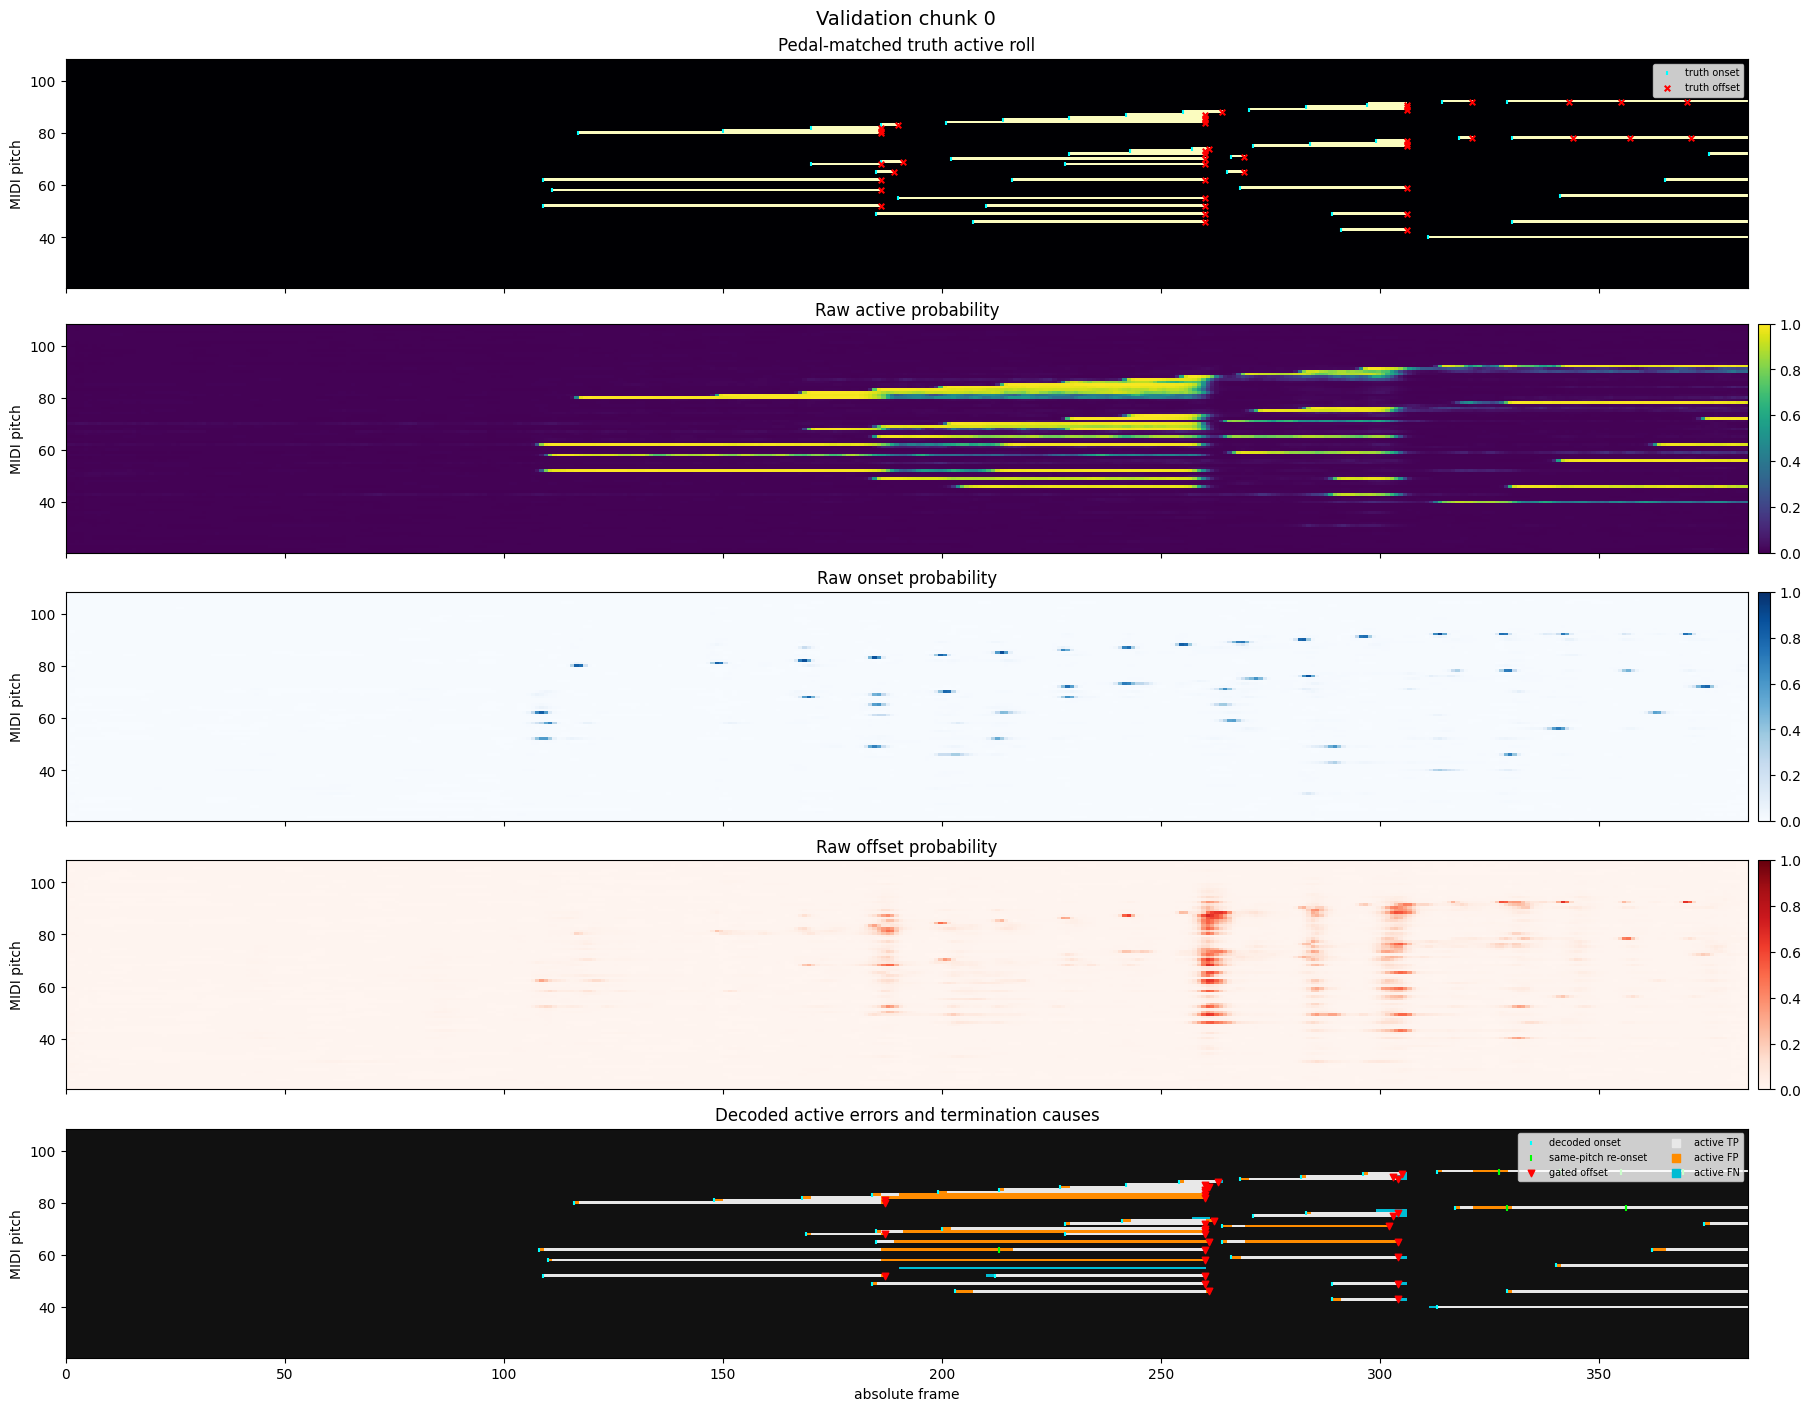

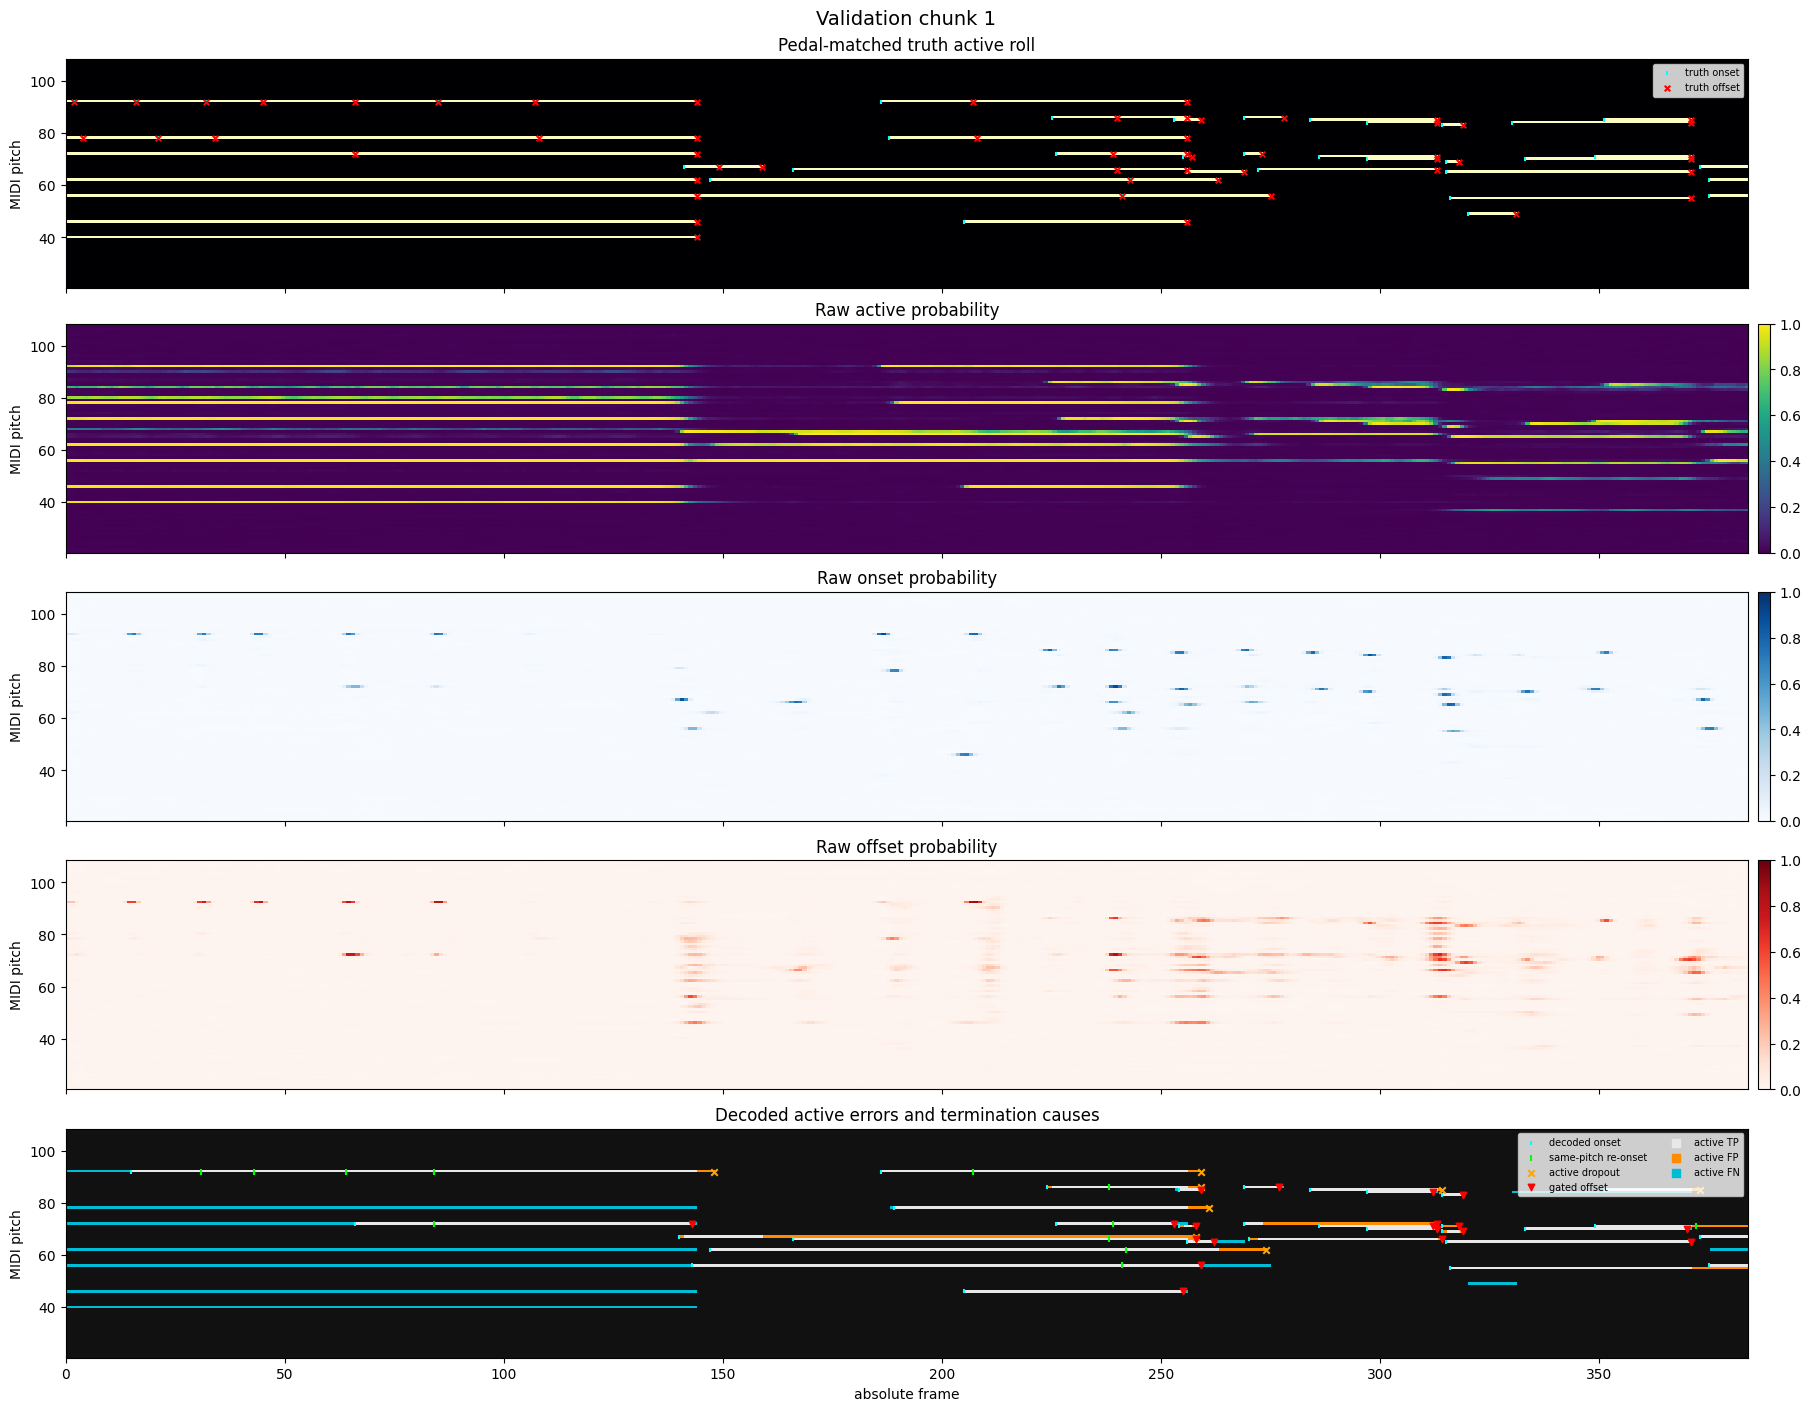

#2: active=0.45 continue=0.40 onset=0.10 offset=0.25 | active_f1=0.708 onset_f1=0.851 score=0.743


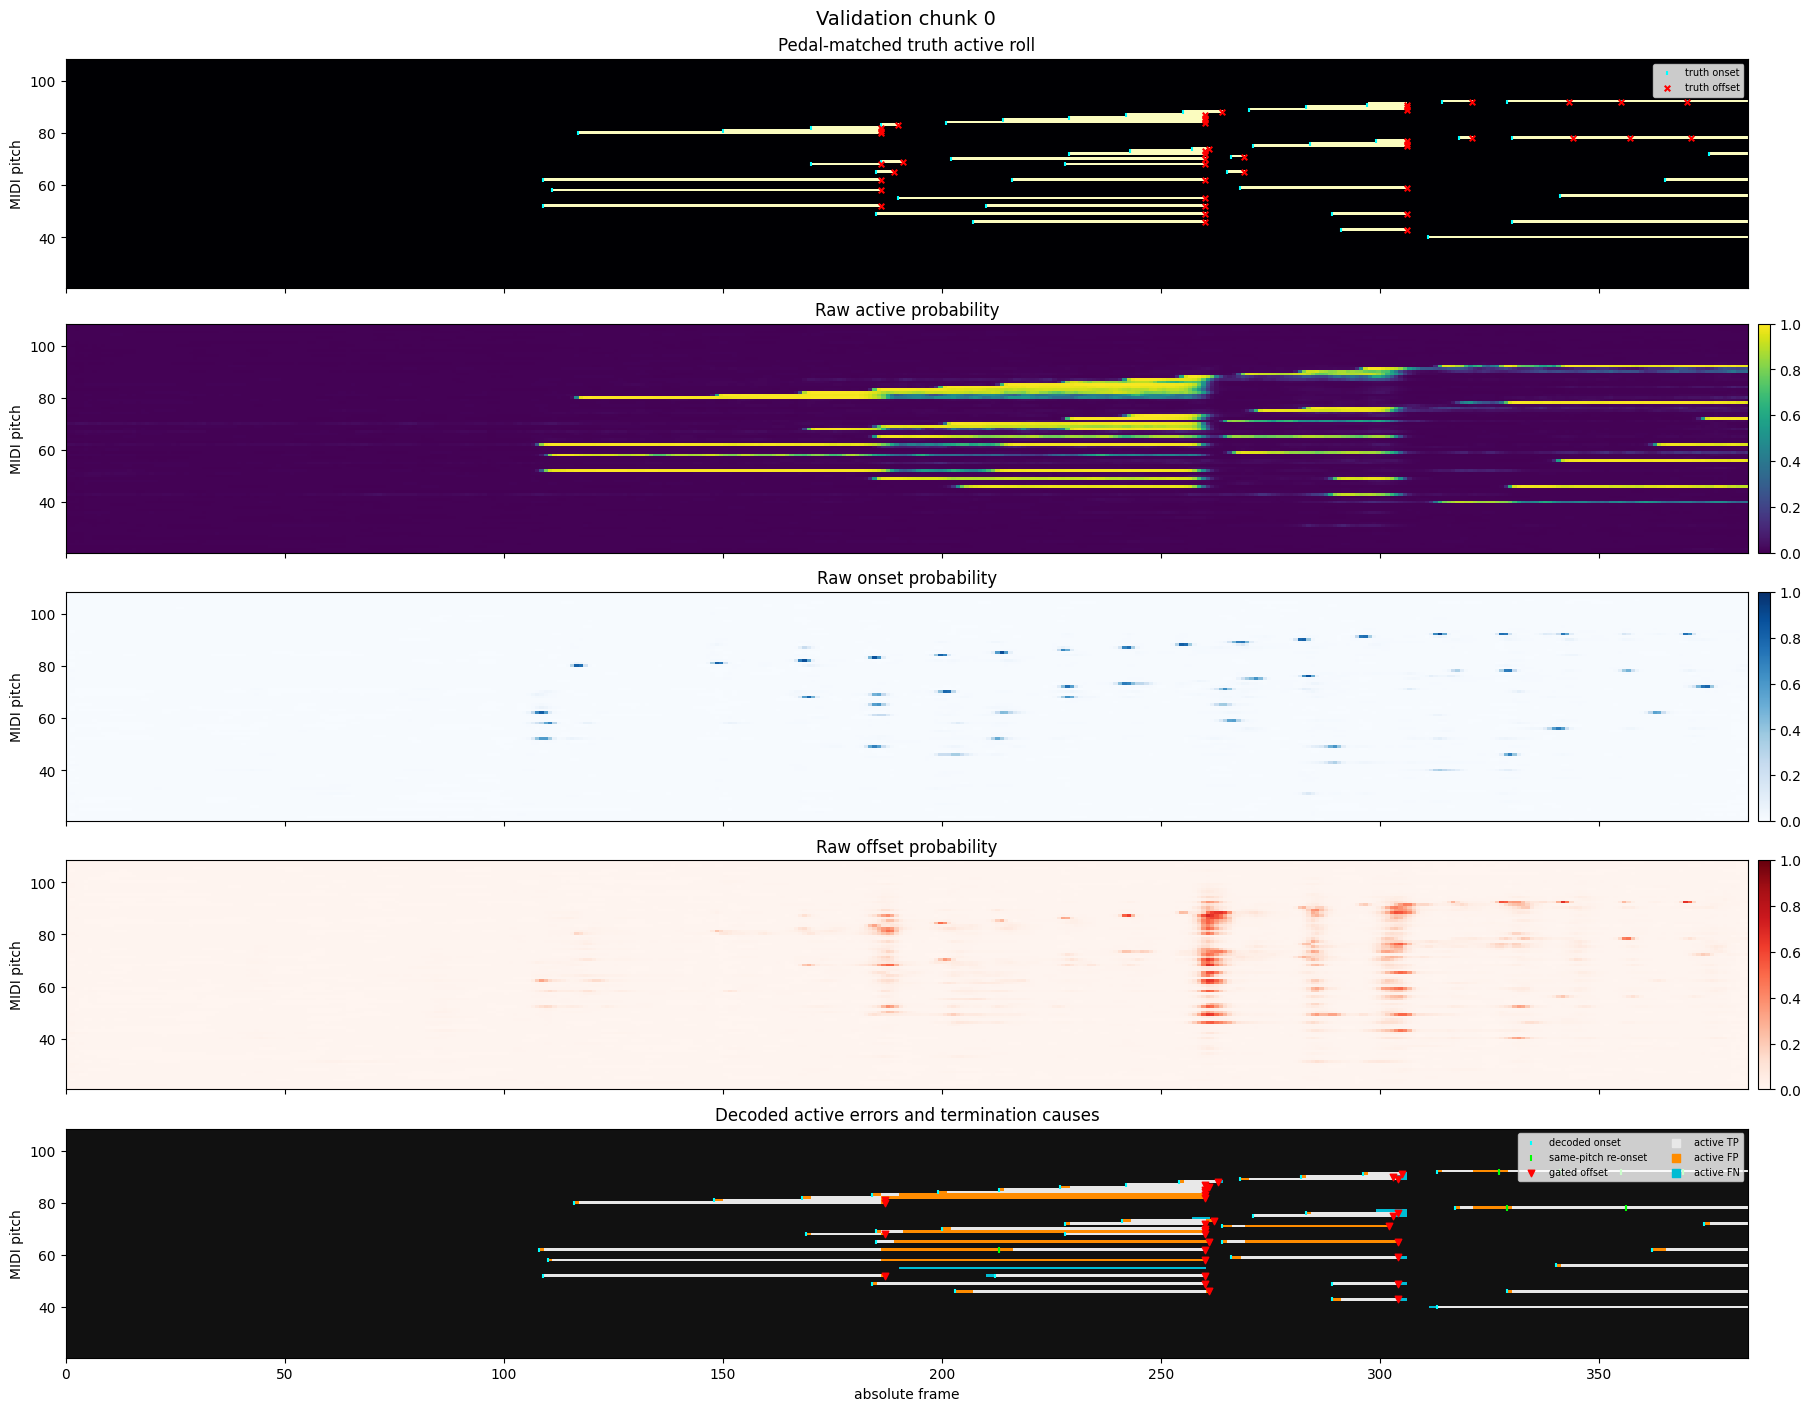

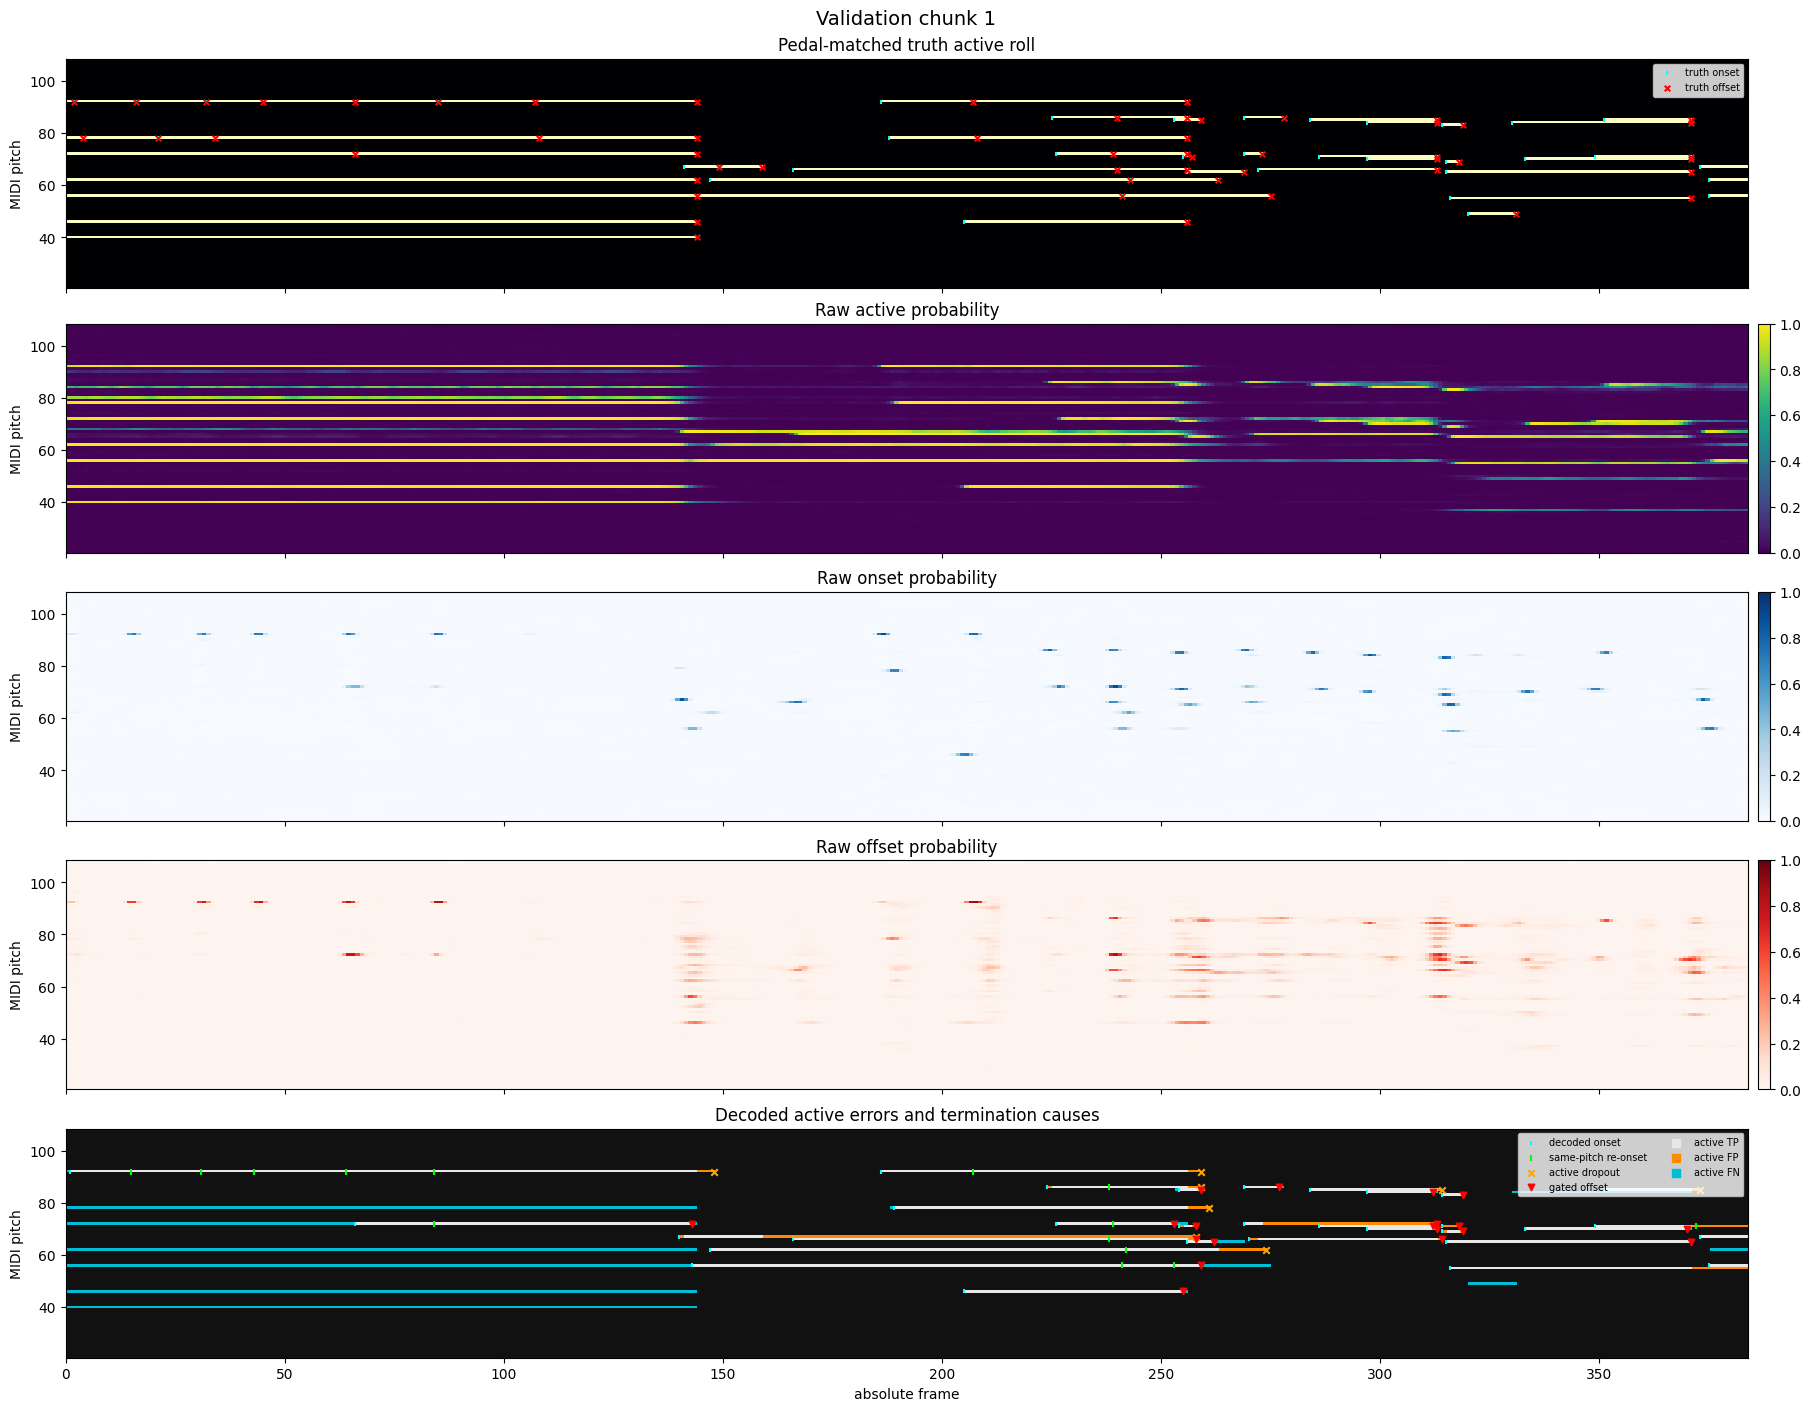

#3: active=0.50 continue=0.40 onset=0.10 offset=0.25 | active_f1=0.708 onset_f1=0.852 score=0.743


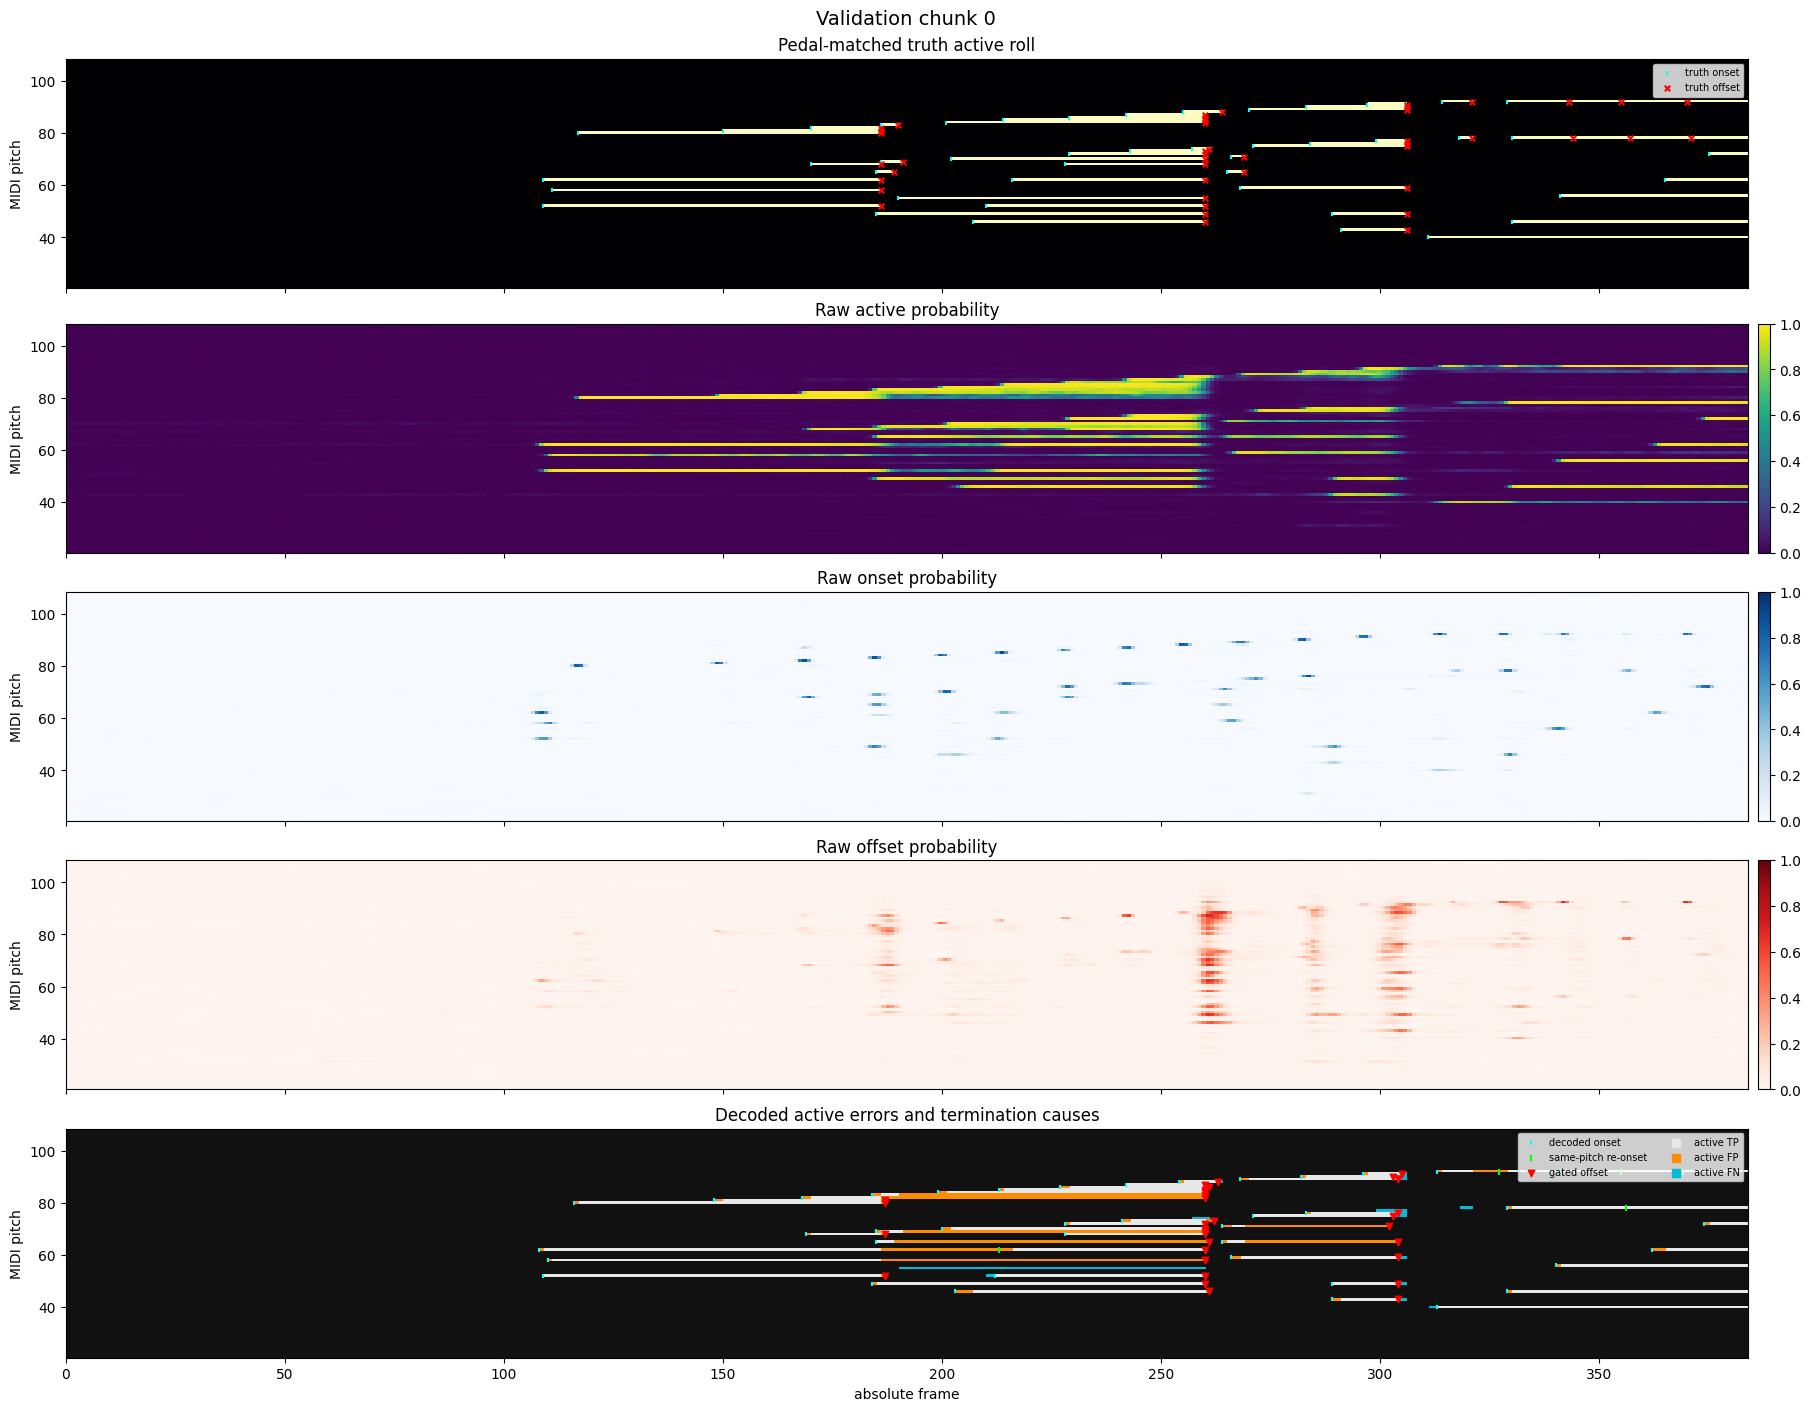

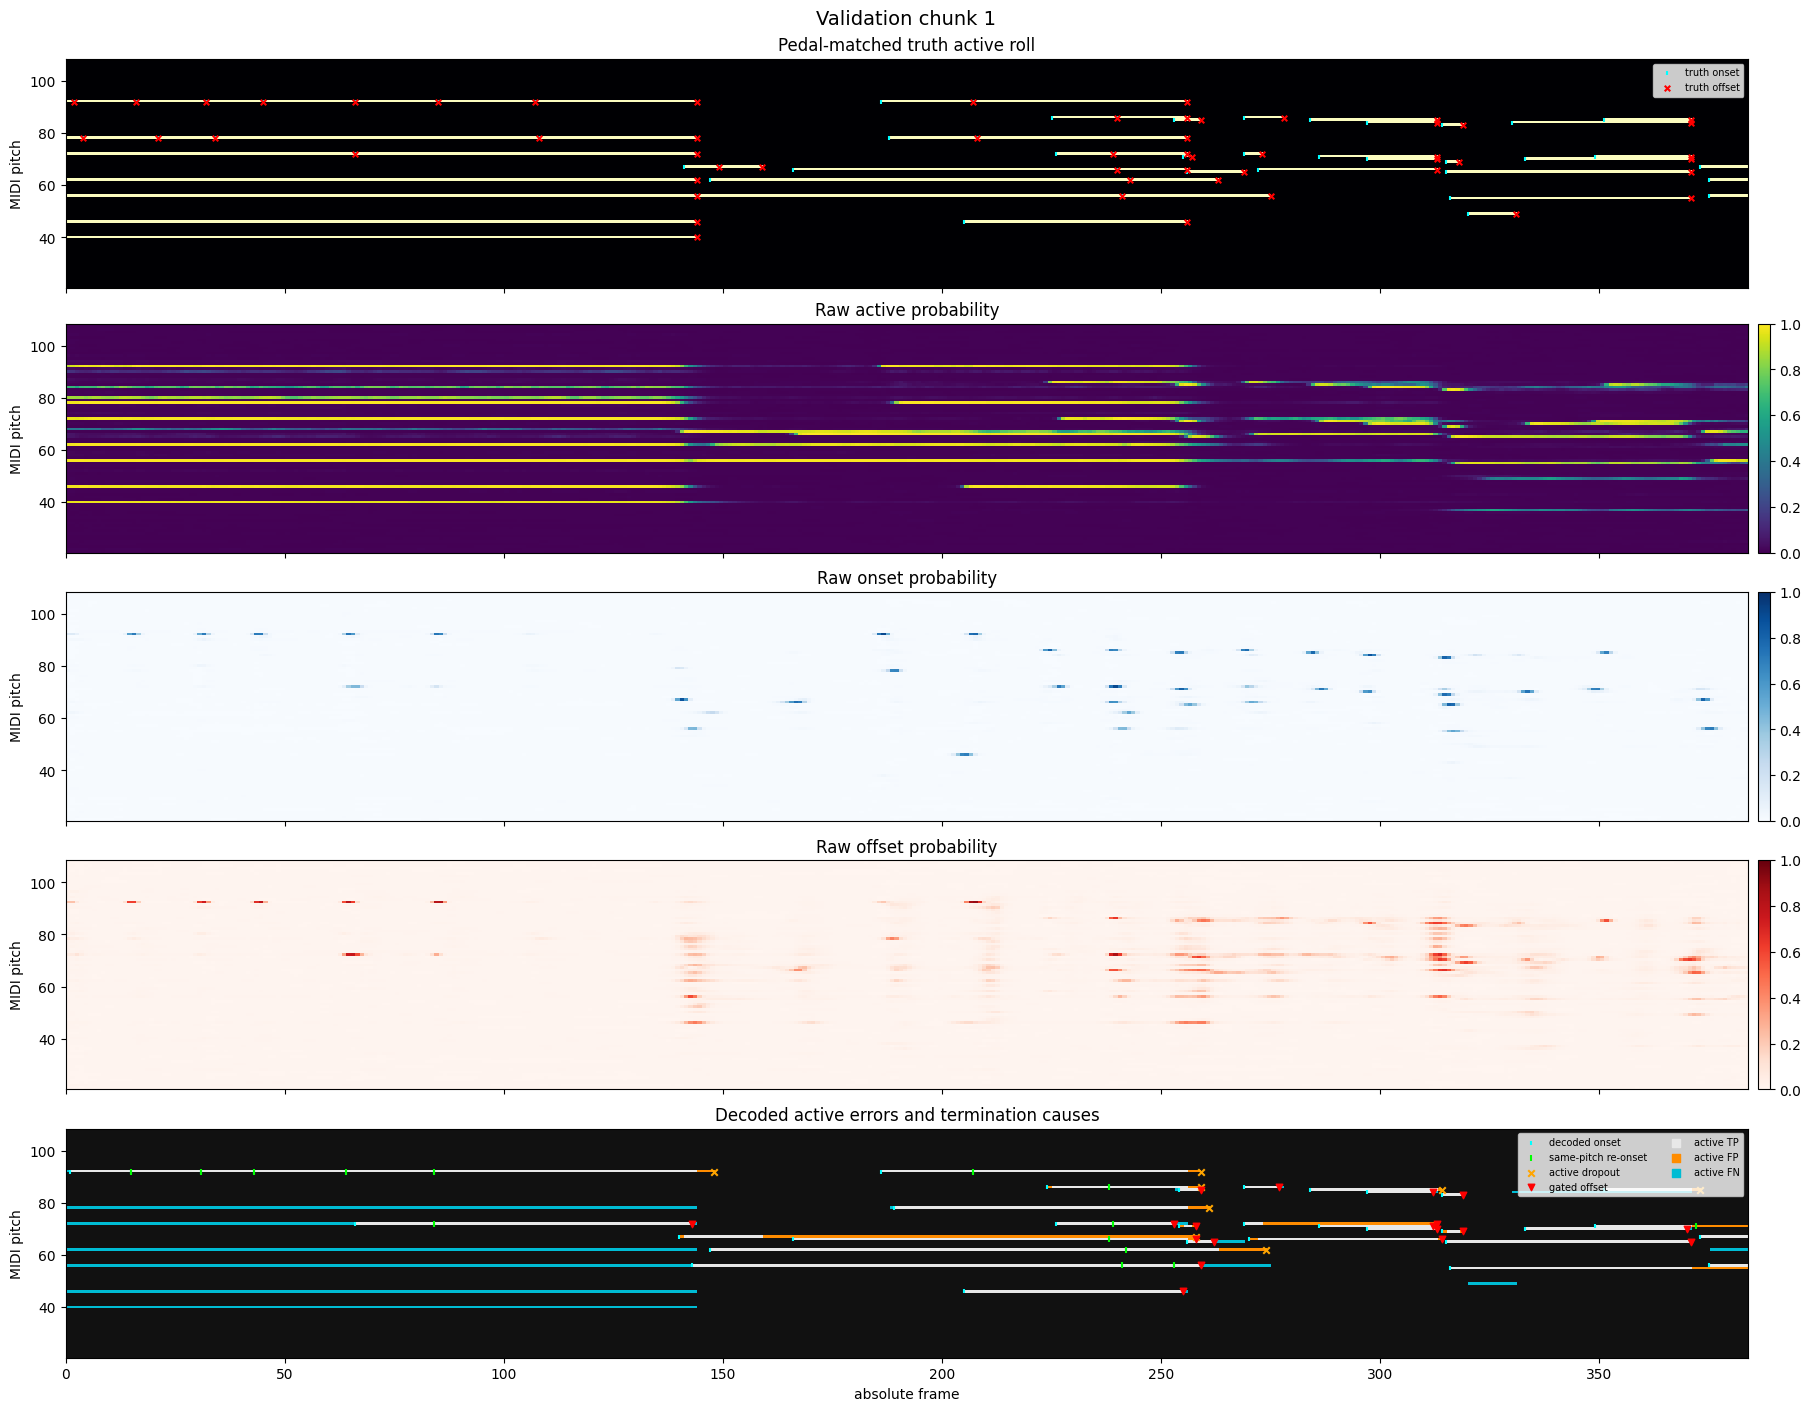

In [ ]:
# Main function for plotting here. It's separate because I use plot_prediction_diagnostics in inference as well
def plot_truth_vs_prediction(
    model,
    dataset,
    idx: int = 0,
    decoder_cfg: DecoderConfig = CFG.decoder,
    frame_range: tuple[int, int] | None = None,
    trace_pitches: list[int] | None = None,
    show_traces: bool = True,
) -> dict:
    
    X, Y = dataset[idx]
    active_prob, onset_prob, offset_prob = predict_chunk(model, X)
    return plot_prediction_diagnostics(
        active_prob,
        onset_prob,
        offset_prob,
        Y.numpy(),
        decoder_cfg=decoder_cfg,
        frame_range=frame_range,
        trace_pitches=trace_pitches,
        show_traces=show_traces,
        title=f"Validation chunk {idx}",
    )


if validation_dataset is not None:
    # Draw a couple of results for the first 3 threshold configurations. It allows us to visually see how thresholds are affecting the predictions.
    for rank, row in threshold_results.head(3).iterrows():
        decoder_cfg = decoder_config_from_row(row)
        print(
            f"#{rank + 1}: active={row['active_threshold']:.2f} continue={row['continue_threshold']:.2f} "
            f"onset={row['onset_threshold']:.2f} offset={decoder_cfg.offset_threshold:.2f} "
            f"| active_f1={row['active_f1']:.3f} onset_f1={row['onset_f1']:.3f} score={row['score']:.3f}"
        )
        # Keep the automatic sweep compact; call the function directly with
        # show_traces=True for detailed pitch traces.
        plot_truth_vs_prediction(
            model, validation_dataset, idx=0, decoder_cfg=decoder_cfg, show_traces=False
        )
        plot_truth_vs_prediction(
            model, validation_dataset, idx=1, decoder_cfg=decoder_cfg, show_traces=False
        )
else:
    print("No val dataset detected to test thresholds with.")


## 11. Inference

In [ ]:
## Find out where to place our sliding chunks
# If we increment by hop_frames we might not land exactly on final_start 
def _full_inference_starts(
    total_frames: int,
    chunk_frames: int,
    hop_frames: int,
) -> list[int]:
    if total_frames <= 0:
        raise ValueError(f"total_frames must be positive, got {total_frames}")
    if chunk_frames <= 0:
        raise ValueError(f"chunk_frames must be positive, got {chunk_frames}")
    if not 0 < hop_frames <= chunk_frames:
        raise ValueError(
            f"hop_frames must be in [1, chunk_frames], got {hop_frames}"
        )
    if total_frames <= chunk_frames:
        return [0]

    final_start = total_frames - chunk_frames
    starts = list(range(0, final_start + 1, hop_frames))
    if starts[-1] != final_start: # Guarantee that every frame in the audio has a chunk
        starts.append(final_start)
    return starts

# We trust edge frames less than center frames, so we give a normalized value that is high in the center and low on edges
def _overlap_blend_weights(
    chunk_frames: int,
    mode: Literal["uniform", "triangular"] = "triangular",
) -> np.ndarray:
    if mode == "uniform":
        return np.ones(chunk_frames, dtype=np.float32)
    if mode != "triangular":
        raise ValueError(f"Unknown overlap blend mode: {mode}")

    position = np.arange(chunk_frames)
    edge_distance = np.minimum(position + 1, chunk_frames - position)
    return (edge_distance / edge_distance.max()).astype(np.float32)

# This is the actual inference function
# We give more weightage to center frames because they have full temporal context (using _overlap_blend_weights)
# We chunk the audio, make batches, get our logits, and turn them into probabilities
@torch.inference_mode()
def predict_full_feature_matrix(
    model,
    features: np.ndarray,
    chunk_frames: int | None = None,
    hop_frames: int | None = None,
    inference_batch_size: int | None = None,
    blend_mode: Literal["uniform", "triangular"] = "triangular",
    device=DEVICE,
    data_cfg: DataConfig = CFG.data,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    
    features = np.asarray(features, dtype=np.float32)
    if features.ndim != 2:
        raise ValueError(f"Expected features with shape (frames, bins), got {features.shape}")
    if len(features) == 0:
        raise ValueError("Cannot transcribe an empty feature matrix.")
    if inference_batch_size <= 0:
        raise ValueError("inference_batch_size must be positive.")

    model.eval()
    chunk_frames = data_cfg.chunk_frames if chunk_frames is None else chunk_frames
    inference_batch_size = (
        data_cfg.inference_batch_size
        if inference_batch_size is None
        else inference_batch_size
    )
    hop_frames = chunk_frames // 2 if hop_frames is None else hop_frames
    total_frames = len(features)
    starts = _full_inference_starts(total_frames, chunk_frames, hop_frames)
    blend = _overlap_blend_weights(chunk_frames, blend_mode)

    probability_sum = np.zeros(
        (total_frames, CFG.feature.n_pitches, N_LABEL_CHANNELS),
        dtype=np.float32,
    )
    weight_sum = np.zeros((total_frames, 1, 1), dtype=np.float32)

    # Accumulate weighted sum
    for batch_index in tqdm(
        range(0, len(starts), inference_batch_size),
        desc="transcribe",
    ):
        batch_starts = starts[batch_index:batch_index + inference_batch_size]
        batch = np.zeros(
            (len(batch_starts), chunk_frames, features.shape[1]),
            dtype=np.float32,
        )
        valid_lengths = []

        for sample, start in enumerate(batch_starts):
            valid = min(chunk_frames, total_frames - start) # In case total frames < chunk frames
            batch[sample, :valid] = features[start:start + valid]
            valid_lengths.append(valid)

        X = torch.from_numpy(batch).unsqueeze(1).to(device, non_blocking=True)
        logits = model(X)
        expected_shape = (
            len(batch_starts),
            chunk_frames,
            CFG.feature.n_pitches,
            N_LABEL_CHANNELS,
        )
        if tuple(logits.shape) != expected_shape:
            raise ValueError(
                f"Model returned {tuple(logits.shape)}; expected {expected_shape}."
            )
        batch_probabilities = torch.sigmoid(logits).cpu().numpy()

        for sample, (start, valid) in enumerate(zip(batch_starts, valid_lengths)):
            end = start + valid
            local_weight = blend[:valid, None, None]
            probability_sum[start:end] += batch_probabilities[sample, :valid] * local_weight
            weight_sum[start:end] += local_weight

    if np.any(weight_sum == 0):
        raise RuntimeError("Internal chunk-planning error left frames uncovered.")

    probabilities = probability_sum / weight_sum
    return (
        probabilities[..., CH_ACTIVE],
        probabilities[..., CH_ONSET],
        probabilities[..., CH_OFFSET],
    )



### Feature-matrix transcription

In [ ]:
# Return probabilities and diagnostic information from pre-extracted features
# It groups the model output as well as decoded probabilities and returns them as one object
def transcribe_feature_matrix(
    model,
    features: np.ndarray,
    decoder_cfg: DecoderConfig | None = None,
    chunk_frames: int | None = None,
    hop_frames: int | None = None,
    inference_batch_size: int | None = None,
    blend_mode: Literal["uniform", "triangular"] = "triangular",
    device=DEVICE,
    data_cfg: DataConfig = CFG.data,
) -> dict:
    decoder_cfg = CFG.decoder if decoder_cfg is None else decoder_cfg
    active_prob, onset_prob, offset_prob = predict_full_feature_matrix(
        model,
        features,
        chunk_frames=chunk_frames,
        hop_frames=hop_frames,
        inference_batch_size=inference_batch_size,
        blend_mode=blend_mode,
        device=device,
        data_cfg=data_cfg,
    )
    labels, decoded_offset, diagnostics = decode_probabilities(
        active_prob,
        onset_prob,
        offset_prob,
        decoder_cfg,
        return_diagnostics=True,
    )
    return {
        "active_prob": active_prob,
        "onset_prob": onset_prob,
        "offset_prob": offset_prob,
        "active": labels[..., CH_ACTIVE],
        "onset": labels[..., CH_ONSET],
        "decoded_offset": decoded_offset,
        "diagnostics": diagnostics,
    }



### MIDI reconstruction

In [ ]:
# Build the MIDI from onset/offset rolls
# We assume that the decoder has resolved note boundaries so every onset should have a corresponding offset
# We just pair them in order and return
def decoded_rolls_to_midi(
    onset: np.ndarray,
    offset: np.ndarray,
    output_path: str | Path | None = None,
    frames_per_second: float | None = None,
    default_velocity: float | None = None,
    tempo: float = 120.0,
    program: int = 0,
) -> pretty_midi.PrettyMIDI:

    frames_per_second = (
        CFG.feature.frames_per_second
        if frames_per_second is None
        else frames_per_second
    )
    onset = np.asarray(onset) > 0.5
    offset = np.asarray(offset) > 0.5

    # Couple of checks to make sure rolls align
    if onset.shape != offset.shape or onset.ndim != 2:
        raise ValueError(
            f"Expected matching (frames, pitches) rolls, got {onset.shape} and {offset.shape}."
        )
    if onset.shape[1] != CFG.feature.n_pitches:
        raise ValueError(f"Expected {CFG.feature.n_pitches} pitches, got {onset.shape[1]}.")
    if frames_per_second <= 0:
        raise ValueError("frames_per_second must be positive.")


    # Just give everything the same velocity for now. I didn't train it
    default_velocity = (
        CFG.decoder.default_velocity
        if default_velocity is None
        else default_velocity
    )
    if not 0 < default_velocity <= 1:
        raise ValueError("default_velocity must be normalized to (0, 1].")

    velocity = int(np.clip(round(default_velocity * 127), 1, 127))
    midi = pretty_midi.PrettyMIDI(initial_tempo=tempo)
    instrument = pretty_midi.Instrument(program=program, name="Piano transcription")
    total_frames = len(onset)

    # This is why you should practice sliding window in leetcode...
    # Advance to the first offset at or after this onset.
    # this offset is now consumed, don't reuse it for the next onset
    for pitch_index, start, end in _paired_note_spans(onset, offset):
        instrument.notes.append(
            pretty_midi.Note(
                velocity=velocity,
                pitch=pitch_index + CFG.feature.midi_low,
                start=float(start) / frames_per_second,
                end=float(end) / frames_per_second,
            )
        )

    instrument.notes.sort(key=lambda note: (note.start, note.pitch, note.end))
    midi.instruments.append(instrument)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        midi.write(str(output_path))

    return midi



### Audio-to-MIDI entry point

In [ ]:
# Main function to convert a wav to midi using our model
def transcribe_audio_to_midi(
    audio_path: str | Path,
    output_midi_path: str | Path,
    model=model,
    cfg: ExperimentConfig = CFG,
    decoder_cfg: DecoderConfig | None = None,
    inference_hop_frames: int | None = None,
    inference_batch_size: int | None = None,
    blend_mode: Literal["uniform", "triangular"] = "triangular",
    default_velocity: float | None = None,
    program: int = 0,
    return_result: bool = False,
) -> Path | tuple[Path, dict]:
    decoder_cfg = decoder_cfg or cfg.decoder
    default_velocity = (
        decoder_cfg.default_velocity
        if default_velocity is None
        else default_velocity
    )
    features = compute_features(audio_path, cfg.feature)
    transcription = transcribe_feature_matrix(
        model,
        features,
        decoder_cfg=decoder_cfg,
        chunk_frames=cfg.data.chunk_frames,
        hop_frames=inference_hop_frames,
        inference_batch_size=inference_batch_size,
        blend_mode=blend_mode,
        data_cfg=cfg.data,
    )

    output_midi_path = Path(output_midi_path)
    decoded_rolls_to_midi(
        transcription["onset"],
        transcription["decoded_offset"],
        output_path=output_midi_path,
        frames_per_second=cfg.feature.frames_per_second,
        default_velocity=default_velocity,
        program=program,
    )

    if return_result:
        return output_midi_path, transcription
    return output_midi_path



### Full-piece checkpoint evaluation

In [ ]:
# Evaluate the model on full pieces and not just chunks (Expensive!)
@torch.inference_mode()
def evaluate_checkpoint_full_piece(
    model, songs: list[tuple[str, str]], decoder_cfg: DecoderConfig, cfg: ExperimentConfig = CFG,
) -> dict:
    per_piece_rows = []
    global_active = np.zeros(3, dtype=np.int64)
    global_onset = np.zeros(3, dtype=np.int64)
    global_onset_offset = np.zeros(3, dtype=np.int64)

    for audio_rel, midi_rel in tqdm(songs, desc="full-piece eval"):
        audio_path = cfg.paths.maestro_root / audio_rel
        midi_path = cfg.paths.maestro_root / midi_rel

        features = compute_features(audio_path, cfg.feature)
        transcription = transcribe_feature_matrix(
            model, features, decoder_cfg=decoder_cfg, data_cfg=cfg.data
        )
        truth = create_targets(midi_path, n_frames=len(features))

        active_counts = binary_counts(
            transcription["active"] > 0.5, truth[..., CH_ACTIVE] > 0.5
        )
        note_metrics = full_piece_note_metrics(
            transcription["onset"], transcription["decoded_offset"],
            truth[..., CH_ONSET], truth[..., CH_OFFSET],
            decoder_cfg.onset_tolerance_frames, decoder_cfg.offset_tolerance_frames,
        )

        active_f1 = counts_to_metrics(*active_counts)["f1"]
        per_piece_rows.append({
            "audio_filename": audio_rel,
            "active_f1": active_f1,
            "note_onset_f1": note_metrics["note_onset_f1"],
            "note_onset_offset_f1": note_metrics["note_onset_offset_f1"],
        })

        global_active += active_counts
        global_onset += (note_metrics["note_onset_tp"], note_metrics["note_onset_fp"], note_metrics["note_onset_fn"])
        global_onset_offset += (note_metrics["note_onset_offset_tp"], note_metrics["note_onset_fp"], note_metrics["note_onset_fn"])

    per_piece_df = pd.DataFrame(per_piece_rows)
    return {
        "per_piece": per_piece_df,
        "mean_active_f1": per_piece_df["active_f1"].mean(),
        "mean_note_onset_f1": per_piece_df["note_onset_f1"].mean(),
        "mean_note_onset_offset_f1": per_piece_df["note_onset_offset_f1"].mean(),
        "micro_active_f1": counts_to_metrics(*global_active)["f1"],
        "micro_note_onset_f1": counts_to_metrics(*global_onset)["f1"],
        "micro_note_onset_offset_f1": counts_to_metrics(*global_onset_offset)["f1"],
    }




### Full-piece evaluation run

In [24]:
validation_songs = get_validation_songs(
    CFG.paths.validation_h5,
    amount=CFG.data.full_piece_validation_song_limit,
)

comparison_rows = []
result = evaluate_checkpoint_full_piece(model, validation_songs, decoder_cfg)
comparison_rows.append({
    "epoch": CFG.train.checkpoint_epoch,
    **{k: v for k, v in result.items() if k != "per_piece"},
})

pd.DataFrame(comparison_rows)

full-piece eval:   0%|          | 0/5 [00:00<?, ?it/s]

transcribe:   0%|          | 0/30 [00:00<?, ?it/s]

transcribe:   0%|          | 0/30 [00:00<?, ?it/s]

transcribe:   0%|          | 0/13 [00:00<?, ?it/s]

transcribe:   0%|          | 0/11 [00:00<?, ?it/s]

transcribe:   0%|          | 0/33 [00:00<?, ?it/s]

,epoch,mean_active_f1,mean_note_onset_f1,mean_note_onset_offset_f1,micro_active_f1,micro_note_onset_f1,micro_note_onset_offset_f1
0,22,0.866278,0.814277,0.753274,0.863955,0.811453,0.752606


In [ ]:
output_path = transcribe_audio_to_midi(
    "/kaggle/input/datasets/wintermelon14/sample/guardian_perfect.wav",
    "/kaggle/working/guardian_perfect.mid",
    decoder_cfg=decoder_cfg
)